Step 1 : Upload Fashion-MNIST CSV files

In [2]:
# ============================================================
# Part 1: Environment Setup - Fashion-MNIST
# ============================================================

import pandas as pd
import numpy as np
import kagglehub


# ============================================================
# Step 1: Download Fashion-MNIST dataset from Kaggle
# ============================================================

path = kagglehub.dataset_download("zalando-research/fashionmnist")

print("Dataset downloaded to:")
print(path)

Dataset downloaded to:
/kaggle/input/datasets/zalando-research/fashionmnist


Step 2 : Load the CSV files

In [3]:
# ============================================================
# Step 2: Load Fashion-MNIST CSV files
# ============================================================

train_df = pd.read_csv(path + "/fashion-mnist_train.csv")
test_df = pd.read_csv(path + "/fashion-mnist_test.csv")


# Display dataset sizes
print("\nTraining data shape:", train_df.shape)
print("Test data shape:", test_df.shape)


# Display first 5 rows
print("\nTraining data:")
display(train_df.head())

print("\nTest data:")
display(test_df.head())




Training data shape: (60000, 785)
Test data shape: (10000, 785)

Training data:


,label,pixel1,pixel2,pixel3,pixel4,pixel5,pixel6,pixel7,pixel8,pixel9,...,pixel775,pixel776,pixel777,pixel778,pixel779,pixel780,pixel781,pixel782,pixel783,pixel784
0,2,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
1,9,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
2,6,0,0,0,0,0,0,0,5,0,...,0,0,0,30,43,0,0,0,0,0
3,0,0,0,0,1,2,0,0,0,0,...,3,0,0,0,0,1,0,0,0,0
4,3,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0



Test data:


,label,pixel1,pixel2,pixel3,pixel4,pixel5,pixel6,pixel7,pixel8,pixel9,...,pixel775,pixel776,pixel777,pixel778,pixel779,pixel780,pixel781,pixel782,pixel783,pixel784
0,0,0,0,0,0,0,0,0,9,8,...,103,87,56,0,0,0,0,0,0,0
1,1,0,0,0,0,0,0,0,0,0,...,34,0,0,0,0,0,0,0,0,0
2,2,0,0,0,0,0,0,14,53,99,...,0,0,0,0,63,53,31,0,0,0
3,2,0,0,0,0,0,0,0,0,0,...,137,126,140,0,133,224,222,56,0,0
4,3,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0


Step 3 : Separate labels and pixel data

In [4]:
# ============================================================
# Step 3: Separate Labels and Pixel Data
# ============================================================

# Separate labels from pixel values
y_all = train_df["label"].to_numpy(dtype=np.int64)
y_test = test_df["label"].to_numpy(dtype=np.int64)

X_all = train_df.drop(columns=["label"]).to_numpy(dtype=np.float32)
X_test = test_df.drop(columns=["label"]).to_numpy(dtype=np.float32)

# Check the shapes
print("Training images shape:", X_all.shape)
print("Training labels shape:", y_all.shape)

print("Test images shape:", X_test.shape)
print("Test labels shape:", y_test.shape)

Training images shape: (60000, 784)
Training labels shape: (60000,)
Test images shape: (10000, 784)
Test labels shape: (10000,)


Step 4 : Normalize Pixel Values

In [5]:
# ============================================================
# Step 4: Normalize Pixel Values
# ============================================================

# Normalize pixel values from 0-255 to 0-1
X_all = X_all / 255.0
X_test = X_test / 255.0

# Check the new range
print("Minimum pixel value:", X_all.min())
print("Maximum pixel value:", X_all.max())

print("\nTraining data shape:", X_all.shape)
print("Test data shape:", X_test.shape)

Minimum pixel value: 0.0
Maximum pixel value: 1.0

Training data shape: (60000, 784)
Test data shape: (10000, 784)


Step 5 : Split Training Data into 80% Training and 20% Validation

In [6]:
# ============================================================
# Step 5: 80/20 Training-Validation Split
# ============================================================

from sklearn.model_selection import train_test_split

# Set random seed for reproducibility
SEED = 42

# Split the original training data into 80% training
# and 20% validation
X_train, X_val, y_train, y_val = train_test_split(
    X_all,
    y_all,
    test_size=0.20,
    random_state=SEED,
    stratify=y_all
)

# Display the number of samples
print("Total training samples :", len(X_all))
print("Training samples       :", len(X_train))
print("Validation samples     :", len(X_val))
print("Provided test samples  :", len(X_test))

# Display shapes
print("\nShapes:")
print("X_train:", X_train.shape)
print("y_train:", y_train.shape)

print("X_val  :", X_val.shape)
print("y_val  :", y_val.shape)

print("X_test :", X_test.shape)
print("y_test :", y_test.shape)

Total training samples : 60000
Training samples       : 48000
Validation samples     : 12000
Provided test samples  : 10000

Shapes:
X_train: (48000, 784)
y_train: (48000,)
X_val  : (12000, 784)
y_val  : (12000,)
X_test : (10000, 784)
y_test : (10000,)


Step 6 : Class Distribution

In [7]:
# ============================================================
# Step 6: Class Distribution
# ============================================================

# Fashion-MNIST class names
CLASS_NAMES = [
    "T-shirt/top",
    "Trouser",
    "Pullover",
    "Dress",
    "Coat",
    "Sandal",
    "Shirt",
    "Sneaker",
    "Bag",
    "Ankle boot"
]

# Function to calculate class distribution
def get_class_distribution(y, split_name):
    counts = np.bincount(y, minlength=10)

    return pd.DataFrame({
        "Split": split_name,
        "Label": range(10),
        "Class": CLASS_NAMES,
        "Count": counts,
        "Percentage": (counts / len(y)) * 100
    })


# Calculate distribution for training and validation
train_distribution = get_class_distribution(
    y_train,
    "Training"
)

validation_distribution = get_class_distribution(
    y_val,
    "Validation"
)


# Combine both tables
class_distribution = pd.concat(
    [
        train_distribution,
        validation_distribution
    ],
    ignore_index=True
)


# Display the result
print("Class Distribution")
print("=" * 60)

display(class_distribution)

Class Distribution


,Split,Label,Class,Count,Percentage
0,Training,0,T-shirt/top,4800,10.0
1,Training,1,Trouser,4800,10.0
2,Training,2,Pullover,4800,10.0
3,Training,3,Dress,4800,10.0
4,Training,4,Coat,4800,10.0
5,Training,5,Sandal,4800,10.0
6,Training,6,Shirt,4800,10.0
7,Training,7,Sneaker,4800,10.0
8,Training,8,Bag,4800,10.0
9,Training,9,Ankle boot,4800,10.0


Part 1 : Step 1: Import Libraries and Set Random Seed

In [8]:
# ============================================================
# PART 1: BACKPROPAGATION FROM SCRATCH
# Step 1: Setup
# ============================================================

import numpy as np
import matplotlib.pyplot as plt

# Random seed for reproducibility
SEED = 42
np.random.seed(SEED)

print("Part 1 started successfully.")
print("Random seed:", SEED)

Part 1 started successfully.
Random seed: 42


Part 1 : Step 2: Select 5,000 Training Samples

In [9]:
# ============================================================
# PART 1: BACKPROPAGATION FROM SCRATCH
# Step 2: Select 5,000 Samples
# ============================================================

# Create a separate random generator using our fixed seed
rng = np.random.default_rng(SEED)

# Randomly select exactly 5,000 samples
subset_indices = rng.choice(
    len(X_train),
    size=5000,
    replace=False
)

# Create the Part 1 subset
X_subset = X_train[subset_indices]
y_subset = y_train[subset_indices]

# Check the result
print("Part 1 dataset:")
print("X_subset shape:", X_subset.shape)
print("y_subset shape:", y_subset.shape)
print("Number of samples:", len(X_subset))

Part 1 dataset:
X_subset shape: (5000, 784)
y_subset shape: (5000,)
Number of samples: 5000


Part 1 : Step 3: Initialize the Network

In [10]:
# ============================================================
# PART 1: BACKPROPAGATION FROM SCRATCH
# Step 3: Initialize Network Parameters
# ============================================================

# Network architecture
INPUT_SIZE = 784
HIDDEN_SIZE = 64
OUTPUT_SIZE = 10

# ------------------------------------------------------------
# Initialize weights
# ------------------------------------------------------------

# W1 connects input layer (784) to hidden layer (64)
W1 = rng.normal(
    loc=0.0,
    scale=np.sqrt(2.0 / INPUT_SIZE),
    size=(INPUT_SIZE, HIDDEN_SIZE)
).astype(np.float32)

# Bias for hidden layer
b1 = np.zeros(
    HIDDEN_SIZE,
    dtype=np.float32
)

# W2 connects hidden layer (64) to output layer (10)
W2 = rng.normal(
    loc=0.0,
    scale=np.sqrt(2.0 / HIDDEN_SIZE),
    size=(HIDDEN_SIZE, OUTPUT_SIZE)
).astype(np.float32)

# Bias for output layer
b2 = np.zeros(
    OUTPUT_SIZE,
    dtype=np.float32
)

# ------------------------------------------------------------
# Display shapes
# ------------------------------------------------------------

print("Network Architecture:")
print("Input layer :", INPUT_SIZE)
print("Hidden layer:", HIDDEN_SIZE)
print("Output layer:", OUTPUT_SIZE)

print("\nParameter shapes:")
print("W1:", W1.shape)
print("b1:", b1.shape)
print("W2:", W2.shape)
print("b2:", b2.shape)

Network Architecture:
Input layer : 784
Hidden layer: 64
Output layer: 10

Parameter shapes:
W1: (784, 64)
b1: (64,)
W2: (64, 10)
b2: (10,)


Part 1 : Step 4: Implement ReLU and Softmax

In [11]:
# ============================================================
# PART 1: BACKPROPAGATION FROM SCRATCH
# Step 4: ReLU and Softmax
# ============================================================

# ------------------------------------------------------------
# ReLU Activation
# ------------------------------------------------------------

def relu(z):
    """
    ReLU activation function.

    ReLU(z) = max(0, z)
    """
    return np.maximum(0, z)


# ------------------------------------------------------------
# ReLU Derivative
# ------------------------------------------------------------

def relu_derivative(z):
    """
    Derivative of ReLU.

    If z > 0, derivative = 1
    If z <= 0, derivative = 0
    """
    return (z > 0).astype(np.float32)


# ------------------------------------------------------------
# Softmax Activation
# ------------------------------------------------------------

def softmax(z):
    """
    Numerically stable Softmax function.
    """

    # Subtract maximum value to prevent numerical overflow
    z_shifted = z - np.max(
        z,
        axis=1,
        keepdims=True
    )

    exp_z = np.exp(z_shifted)

    probabilities = exp_z / np.sum(
        exp_z,
        axis=1,
        keepdims=True
    )

    return probabilities


print("ReLU function created.")
print("ReLU derivative created.")
print("Softmax function created.")

ReLU function created.
ReLU derivative created.
Softmax function created.


Part 1 : Step 5: Implement the Forward Pass

In [12]:
# ============================================================
# PART 1: BACKPROPAGATION FROM SCRATCH
# Step 5: Forward Pass
# ============================================================

def forward_pass(X, W1, b1, W2, b2):
    """
    Performs the forward pass of:

    784 -> 64 -> 10

    Returns:
        probabilities: Softmax output
        cache: values needed during backpropagation
    """

    # --------------------------------------------------------
    # Hidden layer
    # --------------------------------------------------------

    Z1 = X @ W1 + b1

    # ReLU activation
    A1 = relu(Z1)

    # --------------------------------------------------------
    # Output layer
    # --------------------------------------------------------

    Z2 = A1 @ W2 + b2

    # Softmax activation
    A2 = softmax(Z2)

    # --------------------------------------------------------
    # Save intermediate values for backward pass
    # --------------------------------------------------------

    cache = {
        "X": X,
        "Z1": Z1,
        "A1": A1,
        "Z2": Z2,
        "A2": A2
    }

    return A2, cache


print("Forward pass function created successfully.")

Forward pass function created successfully.


Step 6 : Categorical Cross-Entropy Loss

In [13]:
def categorical_cross_entropy(y_true, y_pred):
    """
    Compute mean categorical cross-entropy loss.
    y_true: integer class labels, shape (n_samples,)
    y_pred: predicted probabilities, shape (n_samples, 10)
    """
    n = len(y_true)

    # Select the predicted probability of the correct class
    correct_class_probs = y_pred[np.arange(n), y_true]

    # Avoid log(0)
    correct_class_probs = np.clip(correct_class_probs, 1e-12, 1.0)

    # Mean cross-entropy loss
    loss = -np.mean(np.log(correct_class_probs))

    return loss


# Test the loss function
y_pred_test, _ = forward_pass(X_subset[:10], W1, b1, W2, b2)
loss_test = categorical_cross_entropy(y_subset[:10], y_pred_test)

print("Categorical Cross-Entropy Loss:", loss_test)

Categorical Cross-Entropy Loss: 2.2367792


Step 7 : Prepare One-Hot Labels

In [14]:
def one_hot_encode(y, num_classes=10):
    one_hot = np.zeros((len(y), num_classes), dtype=np.float32)
    one_hot[np.arange(len(y)), y] = 1.0
    return one_hot


Y_subset = one_hot_encode(y_subset)

print("Original labels shape:", y_subset.shape)
print("One-hot labels shape:", Y_subset.shape)
print("\nExample:")
print("Label:", y_subset[0])
print("One-hot:", Y_subset[0])

Original labels shape: (5000,)
One-hot labels shape: (5000, 10)

Example:
Label: 2
One-hot: [0. 0. 1. 0. 0. 0. 0. 0. 0. 0.]


Step 8 : Backward Pass

In [15]:
def backward_pass(y_true_one_hot, cache, W2):
    X = cache["X"]
    Z1 = cache["Z1"]
    A1 = cache["A1"]
    A2 = cache["A2"]

    batch_size = X.shape[0]

    # Output layer gradient
    dZ2 = (A2 - y_true_one_hot) / batch_size

    # Gradients for W2 and b2
    dW2 = A1.T @ dZ2
    db2 = np.sum(dZ2, axis=0)

    # Backpropagate to hidden layer
    dA1 = dZ2 @ W2.T

    # Apply ReLU derivative
    dZ1 = dA1 * relu_derivative(Z1)

    # Gradients for W1 and b1
    dW1 = X.T @ dZ1
    db1 = np.sum(dZ1, axis=0)

    return dW1, db1, dW2, db2


# Test the backward pass
Y_test = Y_subset[:10]

predictions, cache = forward_pass(
    X_subset[:10],
    W1,
    b1,
    W2,
    b2
)

dW1, db1, dW2, db2 = backward_pass(
    Y_test,
    cache,
    W2
)

print("Gradient shapes:")
print("dW1:", dW1.shape)
print("db1:", db1.shape)
print("dW2:", dW2.shape)
print("db2:", db2.shape)

Gradient shapes:
dW1: (784, 64)
db1: (64,)
dW2: (64, 10)
db2: (10,)


Step 9 : Manual Gradient Descent Update

In [16]:
LEARNING_RATE = 0.1

W1_updated = W1 - LEARNING_RATE * dW1
b1_updated = b1 - LEARNING_RATE * db1

W2_updated = W2 - LEARNING_RATE * dW2
b2_updated = b2 - LEARNING_RATE * db2

print("Gradient descent update completed.")

print("\nParameter shapes after update:")
print("W1:", W1_updated.shape)
print("b1:", b1_updated.shape)
print("W2:", W2_updated.shape)
print("b2:", b2_updated.shape)

Gradient descent update completed.

Parameter shapes after update:
W1: (784, 64)
b1: (64,)
W2: (64, 10)
b2: (10,)


Step 10 : Train the Network for 20 Epochs

In [17]:
# Reinitialize weights so training starts from the original state
rng_train = np.random.default_rng(SEED)

W1 = rng_train.normal(
    0,
    np.sqrt(2.0 / INPUT_SIZE),
    size=(INPUT_SIZE, HIDDEN_SIZE)
).astype(np.float32)

b1 = np.zeros(HIDDEN_SIZE, dtype=np.float32)

W2 = rng_train.normal(
    0,
    np.sqrt(2.0 / HIDDEN_SIZE),
    size=(HIDDEN_SIZE, OUTPUT_SIZE)
).astype(np.float32)

b2 = np.zeros(OUTPUT_SIZE, dtype=np.float32)

LEARNING_RATE = 0.1
EPOCHS = 20
BATCH_SIZE = 128

loss_history = []

for epoch in range(EPOCHS):

    # Shuffle training samples
    indices = rng_train.permutation(len(X_subset))

    X_shuffled = X_subset[indices]
    Y_shuffled = Y_subset[indices]

    # Mini-batch gradient descent
    for start in range(0, len(X_subset), BATCH_SIZE):

        end = start + BATCH_SIZE

        X_batch = X_shuffled[start:end]
        Y_batch = Y_shuffled[start:end]

        # Forward pass
        predictions, cache = forward_pass(
            X_batch, W1, b1, W2, b2
        )

        # Backward pass
        dW1, db1, dW2, db2 = backward_pass(
            Y_batch, cache, W2
        )

        # Gradient descent update
        W1 -= LEARNING_RATE * dW1
        b1 -= LEARNING_RATE * db1

        W2 -= LEARNING_RATE * dW2
        b2 -= LEARNING_RATE * db2

    # Calculate loss after each epoch
    train_predictions, _ = forward_pass(
        X_subset, W1, b1, W2, b2
    )

    epoch_loss = categorical_cross_entropy(
        y_subset, train_predictions
    )

    loss_history.append(epoch_loss)

    print(
        f"Epoch {epoch + 1:2d}/{EPOCHS} "
        f"- Loss: {epoch_loss:.4f}"
    )

print("\nTraining completed successfully.")

Epoch  1/20 - Loss: 1.5765
Epoch  2/20 - Loss: 1.2990
Epoch  3/20 - Loss: 0.6732
Epoch  4/20 - Loss: 0.8235
Epoch  5/20 - Loss: 1.5602
Epoch  6/20 - Loss: 2.0969
Epoch  7/20 - Loss: 0.7113
Epoch  8/20 - Loss: 1.5837
Epoch  9/20 - Loss: 0.7862
Epoch 10/20 - Loss: 0.6602
Epoch 11/20 - Loss: 0.7116
Epoch 12/20 - Loss: 0.4505
Epoch 13/20 - Loss: 0.8255
Epoch 14/20 - Loss: 1.1931
Epoch 15/20 - Loss: 0.9617
Epoch 16/20 - Loss: 0.6729
Epoch 17/20 - Loss: 0.5214
Epoch 18/20 - Loss: 0.4708
Epoch 19/20 - Loss: 0.9253
Epoch 20/20 - Loss: 0.4643

Training completed successfully.


Step 11 : Plot Training Loss

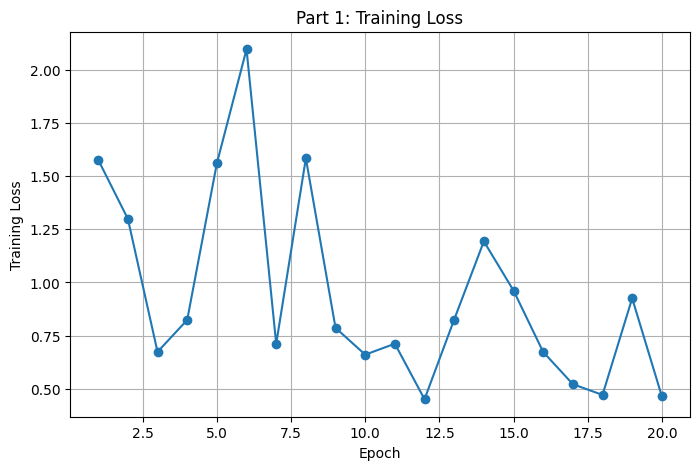

In [18]:
plt.figure(figsize=(8, 5))

plt.plot(
    range(1, EPOCHS + 1),
    loss_history,
    marker="o"
)

plt.xlabel("Epoch")
plt.ylabel("Training Loss")
plt.title("Part 1: Training Loss")
plt.grid(True)

plt.show()

Step 12 : Prepare for Gradient Checking

In [19]:
# Use a small batch for gradient checking
X_check = X_subset[:128]
Y_check = Y_subset[:128]
y_check = y_subset[:128]

# Create fresh initial weights
rng_check = np.random.default_rng(SEED)

W1_check = rng_check.normal(
    0,
    np.sqrt(2.0 / INPUT_SIZE),
    size=(INPUT_SIZE, HIDDEN_SIZE)
).astype(np.float32)

b1_check = np.zeros(HIDDEN_SIZE, dtype=np.float32)

W2_check = rng_check.normal(
    0,
    np.sqrt(2.0 / HIDDEN_SIZE),
    size=(HIDDEN_SIZE, OUTPUT_SIZE)
).astype(np.float32)

b2_check = np.zeros(OUTPUT_SIZE, dtype=np.float32)

# NumPy forward pass
pred_check, cache_check = forward_pass(
    X_check,
    W1_check,
    b1_check,
    W2_check,
    b2_check
)

# NumPy backward pass
dW1_numpy, db1_numpy, dW2_numpy, db2_numpy = backward_pass(
    Y_check,
    cache_check,
    W2_check
)

print("Gradient checking setup completed.")
print("Batch shape:", X_check.shape)
print("NumPy gradients calculated.")

Gradient checking setup completed.
Batch shape: (128, 784)
NumPy gradients calculated.


Step 13 : Build the Same Network in PyTorch

In [20]:
import torch
import torch.nn as nn

# Set PyTorch seed
torch.manual_seed(SEED)

# Define the same network architecture
class SimpleNN(nn.Module):
    def __init__(self):
        super().__init__()

        self.fc1 = nn.Linear(INPUT_SIZE, HIDDEN_SIZE)
        self.fc2 = nn.Linear(HIDDEN_SIZE, OUTPUT_SIZE)

    def forward(self, x):
        x = self.fc1(x)
        x = torch.relu(x)
        x = self.fc2(x)
        return x


# Create PyTorch model
torch_model = SimpleNN()

# Copy the exact NumPy weights into PyTorch
with torch.no_grad():
    torch_model.fc1.weight.copy_(
        torch.tensor(W1_check.T)
    )
    torch_model.fc1.bias.copy_(
        torch.tensor(b1_check)
    )

    torch_model.fc2.weight.copy_(
        torch.tensor(W2_check.T)
    )
    torch_model.fc2.bias.copy_(
        torch.tensor(b2_check)
    )

print("PyTorch model created successfully.")
print(torch_model)

PyTorch model created successfully.
SimpleNN(
  (fc1): Linear(in_features=784, out_features=64, bias=True)
  (fc2): Linear(in_features=64, out_features=10, bias=True)
)


Step 14 : PyTorch Forward and Backward Pass

In [21]:
# Convert NumPy data to PyTorch tensors
X_check_torch = torch.tensor(X_check, dtype=torch.float32)
y_check_torch = torch.tensor(y_check, dtype=torch.long)

# Forward pass
torch_logits = torch_model(X_check_torch)

# Cross-entropy loss
criterion = nn.CrossEntropyLoss()
torch_loss = criterion(torch_logits, y_check_torch)

# Backward pass
torch_model.zero_grad()
torch_loss.backward()

# Extract PyTorch gradients
dW1_torch = torch_model.fc1.weight.grad.detach().numpy().T
db1_torch = torch_model.fc1.bias.grad.detach().numpy()

dW2_torch = torch_model.fc2.weight.grad.detach().numpy().T
db2_torch = torch_model.fc2.bias.grad.detach().numpy()

print("PyTorch loss:", torch_loss.item())

print("\nPyTorch gradients calculated:")
print("dW1:", dW1_torch.shape)
print("db1:", db1_torch.shape)
print("dW2:", dW2_torch.shape)
print("db2:", db2_torch.shape)

PyTorch loss: 2.329271078109741

PyTorch gradients calculated:
dW1: (784, 64)
db1: (64,)
dW2: (64, 10)
db2: (10,)


Step 15 : Compare NumPy and PyTorch Gradients

In [22]:
# Calculate maximum absolute differences
diff_W1 = np.max(np.abs(dW1_numpy - dW1_torch))
diff_b1 = np.max(np.abs(db1_numpy - db1_torch))

diff_W2 = np.max(np.abs(dW2_numpy - dW2_torch))
diff_b2 = np.max(np.abs(db2_numpy - db2_torch))

print("Gradient Check Results")
print("----------------------")
print(f"W1 maximum difference: {diff_W1:.10f}")
print(f"b1 maximum difference: {diff_b1:.10f}")
print(f"W2 maximum difference: {diff_W2:.10f}")
print(f"b2 maximum difference: {diff_b2:.10f}")

max_difference = max(
    diff_W1,
    diff_b1,
    diff_W2,
    diff_b2
)

print("\nOverall maximum difference:", f"{max_difference:.10f}")

if max_difference < 1e-5:
    print("Result: PASS - NumPy and PyTorch gradients match.")
else:
    print("Result: CHECK - Gradient difference is larger than expected.")

Gradient Check Results
----------------------
W1 maximum difference: 0.0000000149
b1 maximum difference: 0.0000000186
W2 maximum difference: 0.0000000224
b2 maximum difference: 0.0000000224

Overall maximum difference: 0.0000000224
Result: PASS — NumPy and PyTorch gradients match.


Step 16 - Part 1 Final Verification

In [23]:
# Make predictions using the trained NumPy network
final_predictions, _ = forward_pass(
    X_subset,
    W1,
    b1,
    W2,
    b2
)

# Convert probabilities to predicted class labels
predicted_labels = np.argmax(final_predictions, axis=1)

# Calculate training accuracy
training_accuracy = np.mean(
    predicted_labels == y_subset
) * 100

# Calculate final training loss
final_loss = categorical_cross_entropy(
    y_subset,
    final_predictions
)

print("Part 1 Final Results")
print("-------------------")
print(f"Final Training Loss    : {final_loss:.4f}")
print(f"Training Accuracy      : {training_accuracy:.2f}%")
print(f"Number of Epochs       : {EPOCHS}")
print(f"Training Samples       : {len(X_subset)}")
print(f"Architecture           : 784 → 64 → 10")
print(f"Gradient Check Max Diff: {max_difference:.10f}")

Part 1 Final Results
-------------------
Final Training Loss    : 0.4643
Training Accuracy      : 83.80%
Number of Epochs       : 20
Training Samples       : 5000
Architecture           : 784 → 64 → 10
Gradient Check Max Diff: 0.0000000224


Part 2 : Step 1: Create a Fixed Baseline Dataset

In [24]:
import torch
import torch.nn as nn
from torch.utils.data import TensorDataset, DataLoader

# Reproducibility
torch.manual_seed(SEED)
np.random.seed(SEED)

# Convert existing train/validation data to PyTorch tensors
X_train_torch = torch.tensor(X_train, dtype=torch.float32)
y_train_torch = torch.tensor(y_train, dtype=torch.long)

X_val_torch = torch.tensor(X_val, dtype=torch.float32)
y_val_torch = torch.tensor(y_val, dtype=torch.long)

# Create datasets
train_dataset = TensorDataset(X_train_torch, y_train_torch)
val_dataset = TensorDataset(X_val_torch, y_val_torch)

# Fixed batch size for all activation experiments
BATCH_SIZE_P2 = 128

train_loader = DataLoader(
    train_dataset,
    batch_size=BATCH_SIZE_P2,
    shuffle=True
)

val_loader = DataLoader(
    val_dataset,
    batch_size=BATCH_SIZE_P2,
    shuffle=False
)

print("Part 2 dataset setup completed.")
print("Training samples:", len(train_dataset))
print("Validation samples:", len(val_dataset))
print("Input features:", X_train.shape[1])
print("Batch size:", BATCH_SIZE_P2)

Part 2 dataset setup completed.
Training samples: 48000
Validation samples: 12000
Input features: 784
Batch size: 128


Part 2 : Step 2: Create the Activation-Based Network

In [25]:
class ActivationNetwork(nn.Module):
    def __init__(self, activation):
        super().__init__()

        self.fc1 = nn.Linear(784, 128)
        self.fc2 = nn.Linear(128, 64)
        self.fc3 = nn.Linear(64, 10)

        self.activation = activation

    def forward(self, x):
        x = self.activation(self.fc1(x))
        x = self.activation(self.fc2(x))
        x = self.fc3(x)

        return x


# Define the four activation functions
activations = {
    "Sigmoid": nn.Sigmoid(),
    "Tanh": nn.Tanh(),
    "ReLU": nn.ReLU(),
    "Leaky ReLU": nn.LeakyReLU(negative_slope=0.01)
}

print("Network architecture:")
print("784 → 128 → 64 → 10")
print("\nActivation functions:")
for name in activations:
    print("-", name)

Network architecture:
784 → 128 → 64 → 10

Activation functions:
- Sigmoid
- Tanh
- ReLU
- Leaky ReLU


Part 2 : Step 3: Create DataLoaders

In [26]:
from torch.utils.data import TensorDataset, DataLoader

# Convert NumPy arrays to PyTorch tensors
X_train_tensor = torch.tensor(X_train, dtype=torch.float32)
y_train_tensor = torch.tensor(y_train, dtype=torch.long)

X_val_tensor = torch.tensor(X_val, dtype=torch.float32)
y_val_tensor = torch.tensor(y_val, dtype=torch.long)

# Create datasets
train_dataset = TensorDataset(
    X_train_tensor,
    y_train_tensor
)

val_dataset = TensorDataset(
    X_val_tensor,
    y_val_tensor
)

# Create DataLoaders
BATCH_SIZE_PART2 = 128

train_loader = DataLoader(
    train_dataset,
    batch_size=BATCH_SIZE_PART2,
    shuffle=True
)

val_loader = DataLoader(
    val_dataset,
    batch_size=BATCH_SIZE_PART2,
    shuffle=False
)

print("Training samples:", len(train_dataset))
print("Validation samples:", len(val_dataset))
print("Batch size:", BATCH_SIZE_PART2)
print("Number of training batches:", len(train_loader))
print("Number of validation batches:", len(val_loader))

Training samples: 48000
Validation samples: 12000
Batch size: 128
Number of training batches: 375
Number of validation batches: 94


Part 2 : Step 4: Set Fixed Training Settings

In [27]:
# Fixed settings for all activation functions
EPOCHS_PART2 = 10
LEARNING_RATE_PART2 = 0.001

criterion_part2 = nn.CrossEntropyLoss()

print("Part 2 training settings:")
print("Epochs:", EPOCHS_PART2)
print("Learning rate:", LEARNING_RATE_PART2)
print("Optimizer: Adam")
print("Loss function: Cross-Entropy Loss")
print("Batch size:", BATCH_SIZE_PART2)

Part 2 training settings:
Epochs: 10
Learning rate: 0.001
Optimizer: Adam
Loss function: Cross-Entropy Loss
Batch size: 128


Part 2 : Step 5: Train One Activation Model

In [28]:
import torch.optim as optim
def train_activation_model(activation_name, activation_function):
    # Create a fresh model
    model = ActivationNetwork(activation_function)

    # Same optimizer and learning rate for every activation
    optimizer = optim.Adam(
        model.parameters(),
        lr=LEARNING_RATE_PART2
    )

    train_losses = []
    val_losses = []

    for epoch in range(EPOCHS_PART2):

        # -------------------------
        # Training
        # -------------------------
        model.train()

        total_train_loss = 0.0

        for X_batch, y_batch in train_loader:

            optimizer.zero_grad()

            outputs = model(X_batch)

            loss = criterion_part2(
                outputs,
                y_batch
            )

            loss.backward()
            optimizer.step()

            total_train_loss += loss.item() * X_batch.size(0)

        average_train_loss = (
            total_train_loss / len(train_loader.dataset)
        )

        # -------------------------
        # Validation
        # -------------------------
        model.eval()

        total_val_loss = 0.0

        with torch.no_grad():
            for X_batch, y_batch in val_loader:

                outputs = model(X_batch)

                loss = criterion_part2(
                    outputs,
                    y_batch
                )

                total_val_loss += loss.item() * X_batch.size(0)

        average_val_loss = (
            total_val_loss / len(val_loader.dataset)
        )

        train_losses.append(average_train_loss)
        val_losses.append(average_val_loss)

        print(
            f"{activation_name} | "
            f"Epoch {epoch + 1}/{EPOCHS_PART2} | "
            f"Train Loss: {average_train_loss:.4f} | "
            f"Val Loss: {average_val_loss:.4f}"
        )

    return model, train_losses, val_losses


print("Training function created successfully.")

Training function created successfully.


Part 2 : Step 6: Train the Four Activation Models

In [29]:
activation_results = {}

for activation_name, activation_function in activations.items():

    print("\n" + "=" * 60)
    print(f"Training with {activation_name}")
    print("=" * 60)

    model, train_losses, val_losses = train_activation_model(
        activation_name,
        activation_function
    )

    activation_results[activation_name] = {
        "model": model,
        "train_losses": train_losses,
        "val_losses": val_losses
    }

print("\nAll four activation models have been trained successfully.")


Training with Sigmoid
Sigmoid | Epoch 1/10 | Train Loss: 1.1266 | Val Loss: 0.6356
Sigmoid | Epoch 2/10 | Train Loss: 0.5316 | Val Loss: 0.4726
Sigmoid | Epoch 3/10 | Train Loss: 0.4337 | Val Loss: 0.4147
Sigmoid | Epoch 4/10 | Train Loss: 0.3927 | Val Loss: 0.3905
Sigmoid | Epoch 5/10 | Train Loss: 0.3669 | Val Loss: 0.3775
Sigmoid | Epoch 6/10 | Train Loss: 0.3471 | Val Loss: 0.3649
Sigmoid | Epoch 7/10 | Train Loss: 0.3362 | Val Loss: 0.3485
Sigmoid | Epoch 8/10 | Train Loss: 0.3218 | Val Loss: 0.3586
Sigmoid | Epoch 9/10 | Train Loss: 0.3124 | Val Loss: 0.3341
Sigmoid | Epoch 10/10 | Train Loss: 0.3022 | Val Loss: 0.3318

Training with Tanh
Tanh | Epoch 1/10 | Train Loss: 0.6214 | Val Loss: 0.4433
Tanh | Epoch 2/10 | Train Loss: 0.4044 | Val Loss: 0.3965
Tanh | Epoch 3/10 | Train Loss: 0.3599 | Val Loss: 0.3614
Tanh | Epoch 4/10 | Train Loss: 0.3402 | Val Loss: 0.3455
Tanh | Epoch 5/10 | Train Loss: 0.3170 | Val Loss: 0.3376
Tanh | Epoch 6/10 | Train Loss: 0.3045 | Val Loss: 0.349

Part 2 : Step 7: Plot the Four Validation Loss Curves

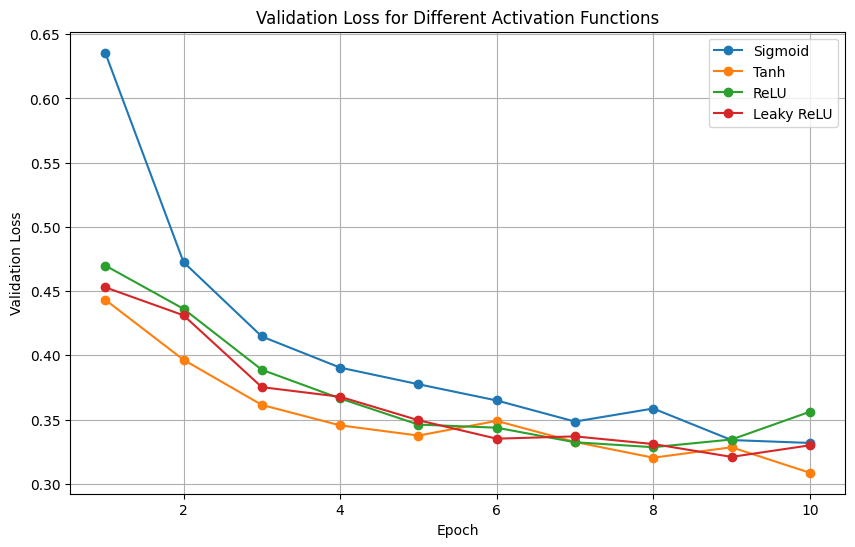

In [30]:
plt.figure(figsize=(10, 6))

for activation_name, results in activation_results.items():
    plt.plot(
        range(1, EPOCHS_PART2 + 1),
        results["val_losses"],
        marker="o",
        label=activation_name
    )

plt.xlabel("Epoch")
plt.ylabel("Validation Loss")
plt.title("Validation Loss for Different Activation Functions")
plt.legend()
plt.grid(True)

plt.show()

Part 2 : Step 8: Calculate Validation Accuracy

In [31]:
def calculate_accuracy(model, data_loader):
    model.eval()

    correct = 0
    total = 0

    with torch.no_grad():
        for X_batch, y_batch in data_loader:
            outputs = model(X_batch)

            predictions = torch.argmax(
                outputs,
                dim=1
            )

            correct += (predictions == y_batch).sum().item()
            total += y_batch.size(0)

    return (correct / total) * 100


activation_accuracy = {}

for activation_name, results in activation_results.items():

    accuracy = calculate_accuracy(
        results["model"],
        val_loader
    )

    activation_accuracy[activation_name] = accuracy

    print(
        f"{activation_name}: "
        f"{accuracy:.2f}% validation accuracy"
    )

Sigmoid: 88.17% validation accuracy
Tanh: 89.01% validation accuracy
ReLU: 86.76% validation accuracy
Leaky ReLU: 87.89% validation accuracy


Part 2 : Step 9: Measure Mean Absolute Gradients

In [32]:
def train_with_gradient_tracking(activation_function):
    model = ActivationNetwork(activation_function)

    optimizer = optim.Adam(
        model.parameters(),
        lr=LEARNING_RATE_PART2
    )

    epoch_gradients = []

    for epoch in range(EPOCHS_PART2):

        model.train()

        total_loss = 0.0

        for X_batch, y_batch in train_loader:

            optimizer.zero_grad()

            outputs = model(X_batch)

            loss = criterion_part2(
                outputs,
                y_batch
            )

            loss.backward()

            # Mean absolute gradient of first hidden layer
            first_layer_gradient = (
                model.fc1.weight.grad
                .abs()
                .mean()
                .item()
            )

            optimizer.step()

            total_loss += loss.item() * X_batch.size(0)

        # Average gradient across all batches in this epoch
        epoch_gradients.append(first_layer_gradient)

    return model, epoch_gradients


# Train Sigmoid and ReLU again while tracking gradients
sigmoid_model, sigmoid_gradients = train_with_gradient_tracking(
    nn.Sigmoid()
)

relu_model, relu_gradients = train_with_gradient_tracking(
    nn.ReLU()
)

print("Gradient tracking completed.")

print("\nSigmoid:")
print(f"Epoch 1 mean absolute gradient: {sigmoid_gradients[0]:.8f}")
print(f"Final epoch mean absolute gradient: {sigmoid_gradients[-1]:.8f}")

print("\nReLU:")
print(f"Epoch 1 mean absolute gradient: {relu_gradients[0]:.8f}")
print(f"Final epoch mean absolute gradient: {relu_gradients[-1]:.8f}")

Gradient tracking completed.

Sigmoid:
Epoch 1 mean absolute gradient: 0.00016441
Final epoch mean absolute gradient: 0.00038127

ReLU:
Epoch 1 mean absolute gradient: 0.00049719
Final epoch mean absolute gradient: 0.00099108


Part 2 : Step 10: Calculate ReLU Dead-Unit Percentage

In [33]:
def calculate_dead_relu_percentage(model, data_loader):
    model.eval()

    total_units = 0
    dead_units = 0

    with torch.no_grad():
        for X_batch, _ in data_loader:

            # First hidden layer pre-activation
            z1 = model.fc1(X_batch)

            # ReLU activation
            a1 = torch.relu(z1)

            # Count zero activations
            dead_units += (a1 == 0).sum().item()
            total_units += a1.numel()

    percentage = (dead_units / total_units) * 100

    return percentage


relu_dead_percentage = calculate_dead_relu_percentage(
    relu_model,
    val_loader
)

print(
    f"ReLU dead-unit percentage: "
    f"{relu_dead_percentage:.2f}%"
)

ReLU dead-unit percentage: 52.00%


Part 2 : Step 11: Compare Sigmoid vs ReLU Gradients

In [34]:
gradient_comparison = pd.DataFrame({
    "Activation": ["Sigmoid", "ReLU"],
    "Epoch 1 Mean |Gradient|": [
        sigmoid_gradients[0],
        relu_gradients[0]
    ],
    "Final Epoch Mean |Gradient|": [
        sigmoid_gradients[-1],
        relu_gradients[-1]
    ]
})

display(gradient_comparison)

,Activation,Epoch 1 Mean |Gradient|,Final Epoch Mean |Gradient|
0,Sigmoid,0.000164,0.000381
1,ReLU,0.000497,0.000991


Step 12: Explanation of Vanishing Gradients and Dead ReLU

Vanishing Gradients

Sigmoid produced smaller first-layer gradients than ReLU, with a mean absolute gradient of **0.000164** in epoch 1 compared with **0.000497** for ReLU. Sigmoid and tanh can produce very small gradients in their saturated regions, causing gradients to shrink during backpropagation and making earlier layers learn slowly. In our experiment, the final Sigmoid gradient (**0.000381**) was also smaller than the final ReLU gradient (**0.000991**).

Dead ReLU

A ReLU neuron becomes "dead" when its input remains negative, producing an output and gradient of zero. In our experiment, approximately **52% of ReLU activations were zero** on the validation data, showing that a large portion of the ReLU units were inactive. Dead neurons may stop learning and contribute little or nothing to the network.

Part 2 : Step 13: Create the Final Comparison Table

In [35]:
part2_summary = pd.DataFrame({
    "Activation": list(activation_results.keys()),
    "Final Validation Loss": [
        activation_results[name]["val_losses"][-1]
        for name in activation_results.keys()
    ],
    "Validation Accuracy (%)": [
        activation_accuracy[name]
        for name in activation_results.keys()
    ]
})

display(part2_summary)

,Activation,Final Validation Loss,Validation Accuracy (%)
0,Sigmoid,0.331837,88.175000
1,Tanh,0.308652,89.008333
2,ReLU,0.356085,86.758333
3,Leaky ReLU,0.329977,87.891667


Part 2 : Step 14: Identify the Best Activation

In [36]:
best_activation = max(
    activation_accuracy,
    key=activation_accuracy.get
)

best_accuracy = activation_accuracy[best_activation]

print("Best Activation Function:", best_activation)
print(f"Validation Accuracy: {best_accuracy:.2f}%")

Best Activation Function: Tanh
Validation Accuracy: 89.01%


Part 2 : Step 15: Record the Part 2 Baseline

In [37]:
part2_baseline_accuracy = best_accuracy

print("Part 2 Baseline Results")
print("----------------------")
print(f"Best Activation: {best_activation}")
print(f"Best Validation Accuracy: {part2_baseline_accuracy:.2f}%")

print("\nThis accuracy will be used as the baseline for Part 7.")

Part 2 Baseline Results
----------------------
Best Activation: Tanh
Best Validation Accuracy: 89.01%

This accuracy will be used as the baseline for Part 7.


Part 3 : Step 1: Prepare the Baseline Architecture for Loss Function Comparison

In [38]:
# ============================================================
# PART 3: LOSS FUNCTIONS
# Step 1: Define Identical Network Architecture
# ============================================================

class LossComparisonNetwork(nn.Module):

    def __init__(self):
        super().__init__()

        self.fc1 = nn.Linear(784, 128)
        self.fc2 = nn.Linear(128, 64)
        self.fc3 = nn.Linear(64, 10)

        self.relu = nn.ReLU()

    def forward(self, x):

        # First hidden layer
        x = self.relu(self.fc1(x))

        # Second hidden layer
        x = self.relu(self.fc2(x))

        # Output layer
        x = self.fc3(x)

        return x


print("Part 3 network created successfully.")
print("Architecture: 784 → 128 → 64 → 10")

Part 3 network created successfully.
Architecture: 784 → 128 → 64 → 10


Part 3 : Step 2: Train with Categorical Cross-Entropy

In [39]:
def train_with_cross_entropy():
    model = LossComparisonNetwork()

    optimizer = optim.Adam(
        model.parameters(),
        lr=0.001
    )

    criterion = nn.CrossEntropyLoss()

    train_losses = []
    val_losses = []

    epochs = 10

    for epoch in range(epochs):

        # -------------------------
        # Training
        # -------------------------
        model.train()

        total_train_loss = 0.0

        for X_batch, y_batch in train_loader:

            optimizer.zero_grad()

            outputs = model(X_batch)

            loss = criterion(outputs, y_batch)

            loss.backward()

            optimizer.step()

            total_train_loss += (
                loss.item() * X_batch.size(0)
            )

        train_loss = (
            total_train_loss /
            len(train_loader.dataset)
        )

        # -------------------------
        # Validation
        # -------------------------
        model.eval()

        total_val_loss = 0.0

        with torch.no_grad():

            for X_batch, y_batch in val_loader:

                outputs = model(X_batch)

                loss = criterion(
                    outputs,
                    y_batch
                )

                total_val_loss += (
                    loss.item() * X_batch.size(0)
                )

        val_loss = (
            total_val_loss /
            len(val_loader.dataset)
        )

        train_losses.append(train_loss)
        val_losses.append(val_loss)

        print(
            f"Epoch {epoch + 1}/{epochs} | "
            f"Train Loss: {train_loss:.4f} | "
            f"Val Loss: {val_loss:.4f}"
        )

    return model, train_losses, val_losses


ce_model, ce_train_losses, ce_val_losses = (
    train_with_cross_entropy()
)

print("\nCross-Entropy training completed.")

Epoch 1/10 | Train Loss: 0.6566 | Val Loss: 0.4875
Epoch 2/10 | Train Loss: 0.4457 | Val Loss: 0.4182
Epoch 3/10 | Train Loss: 0.3976 | Val Loss: 0.4089
Epoch 4/10 | Train Loss: 0.3679 | Val Loss: 0.3616
Epoch 5/10 | Train Loss: 0.3424 | Val Loss: 0.3616
Epoch 6/10 | Train Loss: 0.3251 | Val Loss: 0.3502
Epoch 7/10 | Train Loss: 0.3118 | Val Loss: 0.3394
Epoch 8/10 | Train Loss: 0.3001 | Val Loss: 0.3258
Epoch 9/10 | Train Loss: 0.2902 | Val Loss: 0.3230
Epoch 10/10 | Train Loss: 0.2790 | Val Loss: 0.3223

Cross-Entropy training completed.


Part 3 : Step 3: Prepare One-Hot Targets for MSE

In [43]:
# Convert training and validation labels to one-hot vectors

y_train_onehot = torch.zeros(
    len(y_train),
    10,
    dtype=torch.float32
)

y_train_onehot[
    torch.arange(len(y_train)),
    torch.tensor(y_train)
] = 1.0


y_val_onehot = torch.zeros(
    len(y_val),
    10,
    dtype=torch.float32
)

y_val_onehot[
    torch.arange(len(y_val)),
    torch.tensor(y_val)
] = 1.0


print("Training one-hot shape:", y_train_onehot.shape)
print("Validation one-hot shape:", y_val_onehot.shape)

print("\nExample:")
print("Class label:", y_train[0])
print("One-hot:", y_train_onehot[0])

Training one-hot shape: torch.Size([48000, 10])
Validation one-hot shape: torch.Size([12000, 10])

Example:
Class label: 6
One-hot: tensor([0., 0., 0., 0., 0., 0., 1., 0., 0., 0.])


Part 3 : Step 4: Train with MSE

In [44]:
def train_with_mse():
    model = LossComparisonNetwork()

    optimizer = optim.Adam(
        model.parameters(),
        lr=0.001
    )

    criterion = nn.MSELoss()

    train_losses = []
    val_losses = []

    epochs = 10

    for epoch in range(epochs):

        # -------------------------
        # Training
        # -------------------------
        model.train()

        total_train_loss = 0.0

        for X_batch, y_batch in train_loader:

            # Get one-hot labels for this batch
            batch_indices = y_batch

            targets = torch.zeros(
                len(y_batch),
                10,
                dtype=torch.float32
            )

            targets[
                torch.arange(len(y_batch)),
                batch_indices
            ] = 1.0

            optimizer.zero_grad()

            outputs = model(X_batch)

            # Convert logits to probabilities
            probabilities = torch.softmax(
                outputs,
                dim=1
            )

            loss = criterion(
                probabilities,
                targets
            )

            loss.backward()

            optimizer.step()

            total_train_loss += (
                loss.item() * X_batch.size(0)
            )

        train_loss = (
            total_train_loss /
            len(train_loader.dataset)
        )

        # -------------------------
        # Validation
        # -------------------------
        model.eval()

        total_val_loss = 0.0

        with torch.no_grad():

            for X_batch, y_batch in val_loader:

                targets = torch.zeros(
                    len(y_batch),
                    10,
                    dtype=torch.float32
                )

                targets[
                    torch.arange(len(y_batch)),
                    y_batch
                ] = 1.0

                outputs = model(X_batch)

                probabilities = torch.softmax(
                    outputs,
                    dim=1
                )

                loss = criterion(
                    probabilities,
                    targets
                )

                total_val_loss += (
                    loss.item() * X_batch.size(0)
                )

        val_loss = (
            total_val_loss /
            len(val_loader.dataset)
        )

        train_losses.append(train_loss)
        val_losses.append(val_loss)

        print(
            f"Epoch {epoch + 1}/{epochs} | "
            f"Train Loss: {train_loss:.4f} | "
            f"Val Loss: {val_loss:.4f}"
        )

    return model, train_losses, val_losses


mse_model, mse_train_losses, mse_val_losses = (
    train_with_mse()
)

print("\nMSE training completed.")

Epoch 1/10 | Train Loss: 0.0323 | Val Loss: 0.0237
Epoch 2/10 | Train Loss: 0.0222 | Val Loss: 0.0219
Epoch 3/10 | Train Loss: 0.0201 | Val Loss: 0.0206
Epoch 4/10 | Train Loss: 0.0190 | Val Loss: 0.0194
Epoch 5/10 | Train Loss: 0.0179 | Val Loss: 0.0185
Epoch 6/10 | Train Loss: 0.0171 | Val Loss: 0.0177
Epoch 7/10 | Train Loss: 0.0166 | Val Loss: 0.0177
Epoch 8/10 | Train Loss: 0.0160 | Val Loss: 0.0171
Epoch 9/10 | Train Loss: 0.0156 | Val Loss: 0.0174
Epoch 10/10 | Train Loss: 0.0152 | Val Loss: 0.0170

MSE training completed.


Part 3 : Step 5: Calculate Validation Accuracy

In [45]:
ce_accuracy = calculate_accuracy(
    ce_model,
    val_loader
)

mse_accuracy = calculate_accuracy(
    mse_model,
    val_loader
)

print("Part 3 Loss Comparison")
print("----------------------")
print(f"Cross-Entropy Accuracy: {ce_accuracy:.2f}%")
print(f"MSE Accuracy:           {mse_accuracy:.2f}%")

Part 3 Loss Comparison
----------------------
Cross-Entropy Accuracy: 87.92%
MSE Accuracy:           88.06%


Part 3 : Step 6: Plot CE vs MSE Training Curves

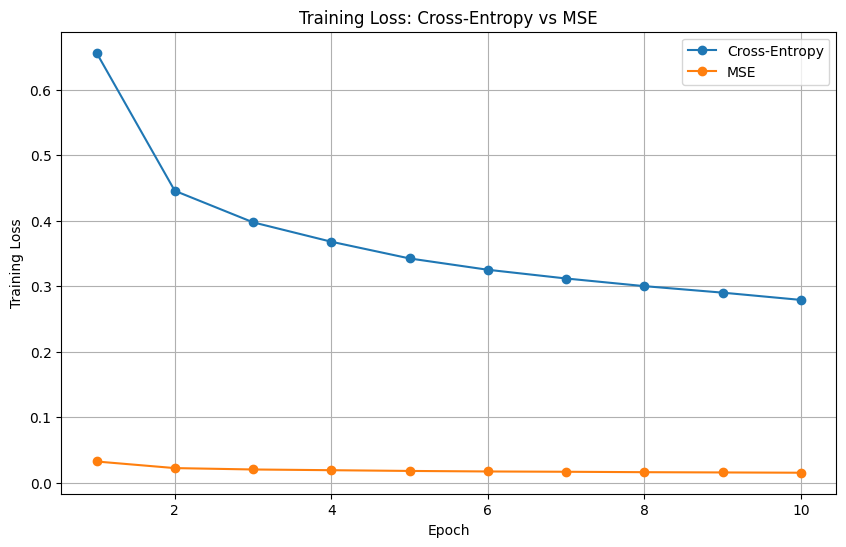

In [46]:
plt.figure(figsize=(10, 6))

plt.plot(
    range(1, 11),
    ce_train_losses,
    marker="o",
    label="Cross-Entropy"
)

plt.plot(
    range(1, 11),
    mse_train_losses,
    marker="o",
    label="MSE"
)

plt.xlabel("Epoch")
plt.ylabel("Training Loss")
plt.title("Training Loss: Cross-Entropy vs MSE")
plt.legend()
plt.grid(True)

plt.show()

Part 3 : Step 7: Create the CE vs MSE Summary Table

In [47]:
part3_loss_comparison = pd.DataFrame({
    "Loss Function": [
        "Cross-Entropy",
        "MSE"
    ],
    "Validation Accuracy (%)": [
        ce_accuracy,
        mse_accuracy
    ],
    "Final Training Loss": [
        ce_train_losses[-1],
        mse_train_losses[-1]
    ],
    "Final Validation Loss": [
        ce_val_losses[-1],
        mse_val_losses[-1]
    ]
})

display(part3_loss_comparison)

,Loss Function,Validation Accuracy (%),Final Training Loss,Final Validation Loss
0,Cross-Entropy,87.925000,0.279047,0.322348
1,MSE,88.058333,0.015172,0.016959


Part 3 : Step 8: Prepare a Tabular Regression Dataset

In [48]:
from sklearn.datasets import fetch_california_housing
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

# Load California Housing regression dataset
housing = fetch_california_housing()

X_reg = housing.data.astype(np.float32)
y_reg = housing.target.astype(np.float32)

print("Dataset shape:")
print("X:", X_reg.shape)
print("y:", y_reg.shape)

# Split into training and validation sets
X_reg_train, X_reg_val, y_reg_train, y_reg_val = train_test_split(
    X_reg,
    y_reg,
    test_size=0.20,
    random_state=SEED
)

# Standardize input features
scaler_reg = StandardScaler()

X_reg_train = scaler_reg.fit_transform(
    X_reg_train
).astype(np.float32)

X_reg_val = scaler_reg.transform(
    X_reg_val
).astype(np.float32)

print("\nAfter split:")
print("Training samples:", len(X_reg_train))
print("Validation samples:", len(X_reg_val))
print("Number of features:", X_reg_train.shape[1])

Dataset shape:
X: (20640, 8)
y: (20640,)

After split:
Training samples: 16512
Validation samples: 4128
Number of features: 8


Part 3 : Step 9: Create the Regression DataLoaders

In [49]:
# Convert regression data to PyTorch tensors
X_reg_train_tensor = torch.tensor(
    X_reg_train,
    dtype=torch.float32
)

y_reg_train_tensor = torch.tensor(
    y_reg_train,
    dtype=torch.float32
).reshape(-1, 1)

X_reg_val_tensor = torch.tensor(
    X_reg_val,
    dtype=torch.float32
)

y_reg_val_tensor = torch.tensor(
    y_reg_val,
    dtype=torch.float32
).reshape(-1, 1)


# Create datasets
reg_train_dataset = TensorDataset(
    X_reg_train_tensor,
    y_reg_train_tensor
)

reg_val_dataset = TensorDataset(
    X_reg_val_tensor,
    y_reg_val_tensor
)


# Create DataLoaders
reg_train_loader = DataLoader(
    reg_train_dataset,
    batch_size=64,
    shuffle=True
)

reg_val_loader = DataLoader(
    reg_val_dataset,
    batch_size=64,
    shuffle=False
)


print("Regression DataLoaders created successfully.")
print("Training samples:", len(reg_train_dataset))
print("Validation samples:", len(reg_val_dataset))
print("Input features:", X_reg_train.shape[1])

Regression DataLoaders created successfully.
Training samples: 16512
Validation samples: 4128
Input features: 8


Part 3 : Step 10: Create the Regression MLP

In [50]:
class RegressionMLP(nn.Module):
    def __init__(self, input_size):
        super().__init__()

        self.network = nn.Sequential(
            nn.Linear(input_size, 32),
            nn.ReLU(),
            nn.Linear(32, 16),
            nn.ReLU(),
            nn.Linear(16, 1)
        )

    def forward(self, x):
        return self.network(x)


# Create regression model
regression_model = RegressionMLP(
    input_size=X_reg_train.shape[1]
)

print("Regression MLP created successfully.")
print(regression_model)

Regression MLP created successfully.
RegressionMLP(
  (network): Sequential(
    (0): Linear(in_features=8, out_features=32, bias=True)
    (1): ReLU()
    (2): Linear(in_features=32, out_features=16, bias=True)
    (3): ReLU()
    (4): Linear(in_features=16, out_features=1, bias=True)
  )
)


Part 3 : Step 11: Train the Regression MLP

In [51]:
# Training settings
REG_EPOCHS = 20
REG_LEARNING_RATE = 0.001

regression_optimizer = optim.Adam(
    regression_model.parameters(),
    lr=REG_LEARNING_RATE
)

regression_criterion = nn.MSELoss()

reg_train_losses = []
reg_val_losses = []


for epoch in range(REG_EPOCHS):

    # -------------------------
    # Training
    # -------------------------
    regression_model.train()

    total_train_loss = 0.0

    for X_batch, y_batch in reg_train_loader:

        regression_optimizer.zero_grad()

        predictions = regression_model(X_batch)

        loss = regression_criterion(
            predictions,
            y_batch
        )

        loss.backward()

        regression_optimizer.step()

        total_train_loss += (
            loss.item() * X_batch.size(0)
        )

    train_loss = (
        total_train_loss /
        len(reg_train_loader.dataset)
    )


    # -------------------------
    # Validation
    # -------------------------
    regression_model.eval()

    total_val_loss = 0.0

    with torch.no_grad():

        for X_batch, y_batch in reg_val_loader:

            predictions = regression_model(X_batch)

            loss = regression_criterion(
                predictions,
                y_batch
            )

            total_val_loss += (
                loss.item() * X_batch.size(0)
            )

    val_loss = (
        total_val_loss /
        len(reg_val_loader.dataset)
    )

    reg_train_losses.append(train_loss)
    reg_val_losses.append(val_loss)

    print(
        f"Epoch {epoch + 1}/{REG_EPOCHS} | "
        f"Train MSE: {train_loss:.4f} | "
        f"Val MSE: {val_loss:.4f}"
    )


print("\nRegression training completed successfully.")

Epoch 1/20 | Train MSE: 1.7156 | Val MSE: 0.6834
Epoch 2/20 | Train MSE: 0.5933 | Val MSE: 0.5062
Epoch 3/20 | Train MSE: 0.4592 | Val MSE: 0.4523
Epoch 4/20 | Train MSE: 0.4250 | Val MSE: 0.4300
Epoch 5/20 | Train MSE: 0.4065 | Val MSE: 0.4131
Epoch 6/20 | Train MSE: 0.3918 | Val MSE: 0.3962
Epoch 7/20 | Train MSE: 0.3818 | Val MSE: 0.3981
Epoch 8/20 | Train MSE: 0.3721 | Val MSE: 0.3791
Epoch 9/20 | Train MSE: 0.3638 | Val MSE: 0.3681
Epoch 10/20 | Train MSE: 0.3553 | Val MSE: 0.3657
Epoch 11/20 | Train MSE: 0.3483 | Val MSE: 0.3639
Epoch 12/20 | Train MSE: 0.3411 | Val MSE: 0.3513
Epoch 13/20 | Train MSE: 0.3363 | Val MSE: 0.3445
Epoch 14/20 | Train MSE: 0.3294 | Val MSE: 0.3383
Epoch 15/20 | Train MSE: 0.3276 | Val MSE: 0.3338
Epoch 16/20 | Train MSE: 0.3203 | Val MSE: 0.3302
Epoch 17/20 | Train MSE: 0.3147 | Val MSE: 0.3239
Epoch 18/20 | Train MSE: 0.3108 | Val MSE: 0.3225
Epoch 19/20 | Train MSE: 0.3089 | Val MSE: 0.3168
Epoch 20/20 | Train MSE: 0.3057 | Val MSE: 0.3216

Regressi

Part 3 : Step 12: Calculate MSE, RMSE, and MAE

In [52]:
from sklearn.metrics import mean_squared_error, mean_absolute_error

# Put model in evaluation mode
regression_model.eval()

all_predictions = []
all_targets = []

with torch.no_grad():

    for X_batch, y_batch in reg_val_loader:

        predictions = regression_model(X_batch)

        all_predictions.extend(
            predictions.squeeze(1).numpy()
        )

        all_targets.extend(
            y_batch.squeeze(1).numpy()
        )


# Convert to NumPy arrays
all_predictions = np.array(all_predictions)
all_targets = np.array(all_targets)


# Calculate metrics
mse = mean_squared_error(
    all_targets,
    all_predictions
)

rmse = np.sqrt(mse)

mae = mean_absolute_error(
    all_targets,
    all_predictions
)


print("Regression Results")
print("------------------")
print(f"MSE  : {mse:.4f}")
print(f"RMSE : {rmse:.4f}")
print(f"MAE  : {mae:.4f}")

Regression Results
------------------
MSE  : 0.3216
RMSE : 0.5671
MAE  : 0.3913


Part 3 : Step 13: Plot the Regression Training Curve

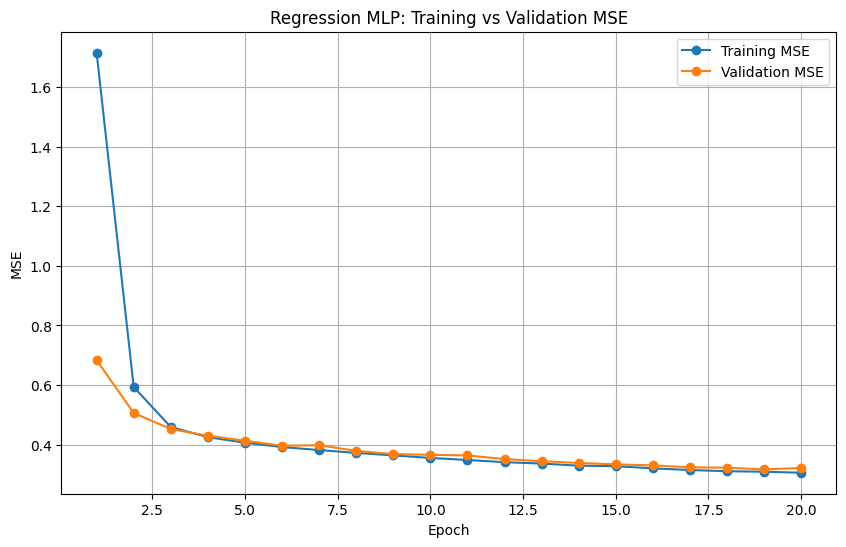

In [53]:
plt.figure(figsize=(10, 6))

plt.plot(
    range(1, REG_EPOCHS + 1),
    reg_train_losses,
    marker="o",
    label="Training MSE"
)

plt.plot(
    range(1, REG_EPOCHS + 1),
    reg_val_losses,
    marker="o",
    label="Validation MSE"
)

plt.xlabel("Epoch")
plt.ylabel("MSE")
plt.title("Regression MLP: Training vs Validation MSE")
plt.legend()
plt.grid(True)

plt.show()

Part 3 : Step 14: Create the Final Part 3 Summary

In [54]:
print("=" * 60)
print("PART 3 — FINAL SUMMARY")
print("=" * 60)

print("\nClassification: Cross-Entropy vs MSE")
print("-------------------------------------")
print(f"Cross-Entropy Validation Accuracy: {ce_accuracy:.2f}%")
print(f"MSE Validation Accuracy:           {mse_accuracy:.2f}%")

print("\nRegression: California Housing")
print("------------------------------")
print(f"MSE  : {mse:.4f}")
print(f"RMSE : {rmse:.4f}")
print(f"MAE  : {mae:.4f}")

print("\nPart 3 completed successfully.")

PART 3 — FINAL SUMMARY

Classification: Cross-Entropy vs MSE
-------------------------------------
Cross-Entropy Validation Accuracy: 87.92%
MSE Validation Accuracy:           88.06%

Regression: California Housing
------------------------------
MSE  : 0.3216
RMSE : 0.5671
MAE  : 0.3913

Part 3 completed successfully.


Part 4 : Step 1: Prepare the Optimizer Comparison

In [55]:
# ============================================================
# PART 4: OPTIMIZER COMPARISON
# Step 1: Setup
# ============================================================

OPTIMIZER_EPOCHS = 10
OPTIMIZER_LR = 0.001

class OptimizerNetwork(nn.Module):
    def __init__(self):
        super().__init__()

        self.network = nn.Sequential(
            nn.Linear(784, 128),
            nn.ReLU(),
            nn.Linear(128, 64),
            nn.ReLU(),
            nn.Linear(64, 10)
        )

    def forward(self, x):
        return self.network(x)


print("Part 4 started successfully.")
print("Architecture: 784 → 128 → 64 → 10")
print("Epochs:", OPTIMIZER_EPOCHS)
print("Initial learning rate:", OPTIMIZER_LR)
print("Loss: Cross-Entropy")

Part 4 started successfully.
Architecture: 784 → 128 → 64 → 10
Epochs: 10
Initial learning rate: 0.001
Loss: Cross-Entropy


Part 4 : Step 2: Create the Optimizer Function

In [56]:
import time

def train_with_optimizer(optimizer_name, learning_rate):

    # Create a fresh model
    model = OptimizerNetwork()

    # Select optimizer
    if optimizer_name == "SGD":
        optimizer = optim.SGD(
            model.parameters(),
            lr=learning_rate
        )

    elif optimizer_name == "SGD + Momentum":
        optimizer = optim.SGD(
            model.parameters(),
            lr=learning_rate,
            momentum=0.9
        )

    elif optimizer_name == "RMSProp":
        optimizer = optim.RMSprop(
            model.parameters(),
            lr=learning_rate
        )

    elif optimizer_name == "Adam":
        optimizer = optim.Adam(
            model.parameters(),
            lr=learning_rate
        )

    criterion = nn.CrossEntropyLoss()

    train_losses = []
    val_losses = []
    val_accuracies = []

    start_time = time.time()

    for epoch in range(OPTIMIZER_EPOCHS):

        # -------------------------
        # Training
        # -------------------------
        model.train()

        total_train_loss = 0.0

        for X_batch, y_batch in train_loader:

            optimizer.zero_grad()

            outputs = model(X_batch)

            loss = criterion(
                outputs,
                y_batch
            )

            loss.backward()
            optimizer.step()

            total_train_loss += (
                loss.item() * X_batch.size(0)
            )

        train_loss = (
            total_train_loss /
            len(train_loader.dataset)
        )

        # -------------------------
        # Validation
        # -------------------------
        model.eval()

        total_val_loss = 0.0
        correct = 0
        total = 0

        with torch.no_grad():

            for X_batch, y_batch in val_loader:

                outputs = model(X_batch)

                loss = criterion(
                    outputs,
                    y_batch
                )

                total_val_loss += (
                    loss.item() * X_batch.size(0)
                )

                predictions = torch.argmax(
                    outputs,
                    dim=1
                )

                correct += (
                    predictions == y_batch
                ).sum().item()

                total += y_batch.size(0)

        val_loss = (
            total_val_loss /
            len(val_loader.dataset)
        )

        val_accuracy = (
            correct / total
        ) * 100

        train_losses.append(train_loss)
        val_losses.append(val_loss)
        val_accuracies.append(val_accuracy)

        print(
            f"{optimizer_name} | "
            f"Epoch {epoch + 1}/{OPTIMIZER_EPOCHS} | "
            f"Train Loss: {train_loss:.4f} | "
            f"Val Loss: {val_loss:.4f} | "
            f"Val Acc: {val_accuracy:.2f}%"
        )

    training_time = time.time() - start_time

    return {
        "model": model,
        "train_losses": train_losses,
        "val_losses": val_losses,
        "val_accuracies": val_accuracies,
        "time": training_time
    }


print("Optimizer training function created successfully.")

Optimizer training function created successfully.


Part 4 : Step 3: Train the Four Optimizers

In [57]:
optimizer_results = {}

optimizer_names = [
    "SGD",
    "SGD + Momentum",
    "RMSProp",
    "Adam"
]

for optimizer_name in optimizer_names:

    print("\n" + "=" * 70)
    print(f"Training with {optimizer_name}")
    print("=" * 70)

    result = train_with_optimizer(
        optimizer_name,
        OPTIMIZER_LR
    )

    optimizer_results[optimizer_name] = result

print("\nAll four optimizers have been trained successfully.")


Training with SGD
SGD | Epoch 1/10 | Train Loss: 2.2852 | Val Loss: 2.2669 | Val Acc: 14.95%
SGD | Epoch 2/10 | Train Loss: 2.2508 | Val Loss: 2.2337 | Val Acc: 26.59%
SGD | Epoch 3/10 | Train Loss: 2.2155 | Val Loss: 2.1948 | Val Acc: 28.93%
SGD | Epoch 4/10 | Train Loss: 2.1726 | Val Loss: 2.1469 | Val Acc: 30.72%
SGD | Epoch 5/10 | Train Loss: 2.1189 | Val Loss: 2.0860 | Val Acc: 35.17%
SGD | Epoch 6/10 | Train Loss: 2.0500 | Val Loss: 2.0078 | Val Acc: 37.83%
SGD | Epoch 7/10 | Train Loss: 1.9626 | Val Loss: 1.9107 | Val Acc: 40.50%
SGD | Epoch 8/10 | Train Loss: 1.8575 | Val Loss: 1.7972 | Val Acc: 42.77%
SGD | Epoch 9/10 | Train Loss: 1.7382 | Val Loss: 1.6734 | Val Acc: 49.99%
SGD | Epoch 10/10 | Train Loss: 1.6143 | Val Loss: 1.5499 | Val Acc: 57.17%

Training with SGD + Momentum
SGD + Momentum | Epoch 1/10 | Train Loss: 2.1308 | Val Loss: 1.7294 | Val Acc: 55.86%
SGD + Momentum | Epoch 2/10 | Train Loss: 1.2774 | Val Loss: 0.9952 | Val Acc: 64.16%
SGD + Momentum | Epoch 3/10 

Part 4 : Step 4: Create the Optimizer Comparison Table

In [58]:
optimizer_table = pd.DataFrame({
    "Optimizer": optimizer_names,
    "Learning Rate": [
        OPTIMIZER_LR
    ] * len(optimizer_names),
    "Final Validation Accuracy (%)": [
        optimizer_results[name]["val_accuracies"][-1]
        for name in optimizer_names
    ],
    "Final Validation Loss": [
        optimizer_results[name]["val_losses"][-1]
        for name in optimizer_names
    ],
    "Wall-Clock Time (seconds)": [
        optimizer_results[name]["time"]
        for name in optimizer_names
    ]
})

display(optimizer_table)

,Optimizer,Learning Rate,Final Validation Accuracy (%),Final Validation Loss,Wall-Clock Time (seconds)
0,SGD,0.001,57.166667,1.549876,10.836240
1,SGD + Momentum,0.001,80.733333,0.541638,11.583049
2,RMSProp,0.001,88.683333,0.313655,12.587163
3,Adam,0.001,87.183333,0.354039,14.315406


Part 4 : Step 5: Define Learning Rates for Tuning

In [59]:
# Learning rates to test for each optimizer
learning_rates = {
    "SGD": [0.01, 0.05, 0.1],
    "SGD + Momentum": [0.01, 0.05, 0.1],
    "RMSProp": [0.0001, 0.0005, 0.001],
    "Adam": [0.0001, 0.0005, 0.001]
}

print("Learning-rate search space:")
for optimizer_name, rates in learning_rates.items():
    print(f"{optimizer_name}: {rates}")

Learning-rate search space:
SGD: [0.01, 0.05, 0.1]
SGD + Momentum: [0.01, 0.05, 0.1]
RMSProp: [0.0001, 0.0005, 0.001]
Adam: [0.0001, 0.0005, 0.001]


Part 4 : Step 6: Run Learning-Rate Tuning

In [61]:
tuning_results = []

for optimizer_name, rates in learning_rates.items():

    print("\n" + "#" * 70)
    print(f"Tuning {optimizer_name}")
    print("#" * 70)

    for lr in rates:

        print(f"\nTesting learning rate: {lr}")

        result = train_with_optimizer(
            optimizer_name,
            lr
        )

        tuning_results.append({
            "Optimizer": optimizer_name,
            "Learning Rate": lr,
            "Final Validation Accuracy (%)":
                result["val_accuracies"][-1],
            "Final Validation Loss":
                result["val_losses"][-1],
            "Wall-Clock Time (seconds)":
                result["time"]
        })

print("\nLearning-rate tuning completed.")


######################################################################
Tuning SGD
######################################################################

Testing learning rate: 0.01
SGD | Epoch 1/10 | Train Loss: 1.9189 | Val Loss: 1.3821 | Val Acc: 56.66%
SGD | Epoch 2/10 | Train Loss: 1.1142 | Val Loss: 0.9363 | Val Acc: 66.04%
SGD | Epoch 3/10 | Train Loss: 0.8567 | Val Loss: 0.7871 | Val Acc: 70.10%
SGD | Epoch 4/10 | Train Loss: 0.7452 | Val Loss: 0.7072 | Val Acc: 73.65%
SGD | Epoch 5/10 | Train Loss: 0.6779 | Val Loss: 0.6466 | Val Acc: 76.92%
SGD | Epoch 6/10 | Train Loss: 0.6296 | Val Loss: 0.6090 | Val Acc: 78.17%
SGD | Epoch 7/10 | Train Loss: 0.5949 | Val Loss: 0.5740 | Val Acc: 79.81%
SGD | Epoch 8/10 | Train Loss: 0.5672 | Val Loss: 0.5574 | Val Acc: 80.39%
SGD | Epoch 9/10 | Train Loss: 0.5469 | Val Loss: 0.5423 | Val Acc: 80.47%
SGD | Epoch 10/10 | Train Loss: 0.5292 | Val Loss: 0.5177 | Val Acc: 81.83%

Testing learning rate: 0.05
SGD | Epoch 1/10 | Train Loss: 1.1303

Part 4 : Step 7: Display the Learning-Rate Tuning Results

In [62]:
tuning_table = pd.DataFrame(tuning_results)

# Sort by optimizer and validation accuracy
tuning_table = tuning_table.sort_values(
    ["Optimizer", "Final Validation Accuracy (%)"],
    ascending=[True, False]
).reset_index(drop=True)

display(tuning_table)

,Optimizer,Learning Rate,Final Validation Accuracy (%),Final Validation Loss,Wall-Clock Time (seconds)
0,Adam,0.0010,88.133333,0.323956,14.011853
1,Adam,0.0005,87.508333,0.341718,13.869716
2,Adam,0.0001,85.125000,0.421642,13.787139
3,RMSProp,0.0010,88.508333,0.319382,12.867819
4,RMSProp,0.0005,87.466667,0.346714,12.690842
5,RMSProp,0.0001,84.975000,0.424796,12.203140
6,SGD,0.0500,86.225000,0.382155,11.028361
7,SGD,0.1000,85.891667,0.379403,11.089847
8,SGD,0.0100,81.825000,0.517693,10.871055
9,SGD + Momentum,0.0500,87.483333,0.343949,11.561866


Part 4 : Step 8: Find the Best Learning Rate for Each Optimizer

In [63]:
best_lr_results = (
    tuning_table
    .loc[
        tuning_table.groupby("Optimizer")[
            "Final Validation Accuracy (%)"
        ].idxmax()
    ]
    .sort_values("Final Validation Accuracy (%)", ascending=False)
    .reset_index(drop=True)
)

print("Best Learning Rate for Each Optimizer:")
display(best_lr_results)

Best Learning Rate for Each Optimizer:


,Optimizer,Learning Rate,Final Validation Accuracy (%),Final Validation Loss,Wall-Clock Time (seconds)
0,RMSProp,0.001,88.508333,0.319382,12.867819
1,Adam,0.001,88.133333,0.323956,14.011853
2,SGD + Momentum,0.050,87.483333,0.343949,11.561866
3,SGD,0.050,86.225000,0.382155,11.028361


Part 4 : Step 9: Plot Training Loss Curves

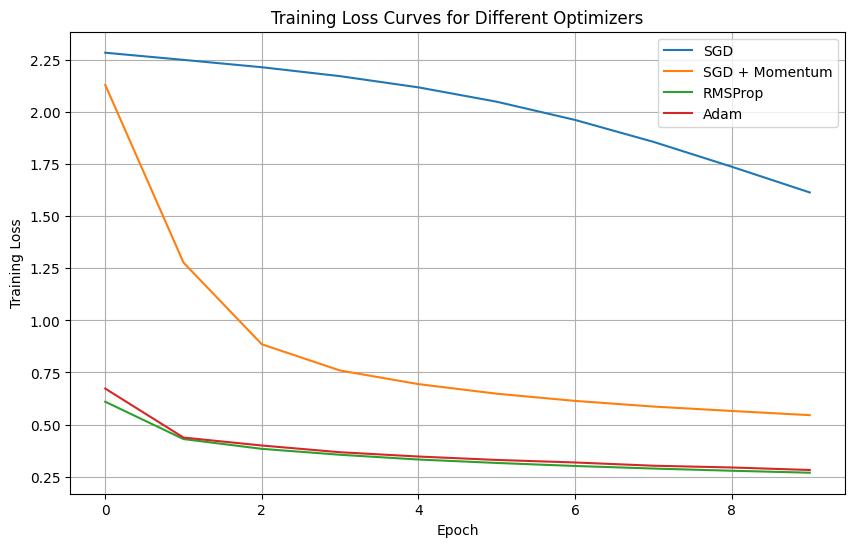

In [64]:
plt.figure(figsize=(10, 6))

for optimizer_name, result in optimizer_results.items():
    plt.plot(
        result["train_losses"],
        label=optimizer_name
    )

plt.xlabel("Epoch")
plt.ylabel("Training Loss")
plt.title("Training Loss Curves for Different Optimizers")
plt.legend()
plt.grid(True)
plt.show()

Part 4 : Step 10: Select the Best Optimizer

In [65]:
best_optimizer_row = best_lr_results.iloc[0]

best_optimizer = best_optimizer_row["Optimizer"]
best_learning_rate = best_optimizer_row["Learning Rate"]
best_validation_accuracy = best_optimizer_row["Final Validation Accuracy (%)"]

print("Best Optimizer:", best_optimizer)
print("Best Learning Rate:", best_learning_rate)
print("Final Validation Accuracy:", round(best_validation_accuracy, 2), "%")

Best Optimizer: RMSProp
Best Learning Rate: 0.001
Final Validation Accuracy: 88.51 %


Part 4 : Step 11: Optimizer Selection & Rationale

In [66]:
print("Optimizer Selection Rationale")
print("-" * 60)

print(
    f"{best_optimizer} was selected because it achieved the highest "
    f"final validation accuracy of {best_validation_accuracy:.2f}% "
    f"with a learning rate of {best_learning_rate}."
)

print(
    "It provides the best validation performance among the tested "
    "optimizer and learning-rate configurations, making it the most "
    "suitable choice for the next experiments."
)

Optimizer Selection Rationale
------------------------------------------------------------
RMSProp was selected because it achieved the highest final validation accuracy of 88.51% with a learning rate of 0.001.
It provides the best validation performance among the tested optimizer and learning-rate configurations, making it the most suitable choice for the next experiments.


Part 4 : Step 12: Create Final Optimizer Summary Table

In [67]:
final_optimizer_summary = best_lr_results[
    [
        "Optimizer",
        "Learning Rate",
        "Final Validation Accuracy (%)",
        "Final Validation Loss",
        "Wall-Clock Time (seconds)"
    ]
].copy()

# Round numerical values for a cleaner table
final_optimizer_summary["Final Validation Accuracy (%)"] = (
    final_optimizer_summary["Final Validation Accuracy (%)"].round(2)
)

final_optimizer_summary["Final Validation Loss"] = (
    final_optimizer_summary["Final Validation Loss"].round(4)
)

final_optimizer_summary["Wall-Clock Time (seconds)"] = (
    final_optimizer_summary["Wall-Clock Time (seconds)"].round(2)
)

display(final_optimizer_summary)

,Optimizer,Learning Rate,Final Validation Accuracy (%),Final Validation Loss,Wall-Clock Time (seconds)
0,RMSProp,0.001,88.51,0.3194,12.87
1,Adam,0.001,88.13,0.3240,14.01
2,SGD + Momentum,0.050,87.48,0.3439,11.56
3,SGD,0.050,86.22,0.3822,11.03


Part 4 : Step 13: Record Epochs Needed to Reach 85% Validation Accuracy

In [68]:
# ---------------------------------------------------------
# Part 4: Learning Rate Tuning with Epochs to 85% Accuracy
# ---------------------------------------------------------

tuning_results_complete = []

for optimizer_name, rates in learning_rates.items():

    print("\n" + "#" * 70)
    print(f"Tuning {optimizer_name}")
    print("#" * 70)

    for lr in rates:

        print(f"\nTesting learning rate: {lr}")

        # Train model
        result = train_with_optimizer(
            optimizer_name,
            lr
        )

        # Find the first epoch where validation accuracy >= 85%
        epochs_to_85 = None

        for epoch_number, accuracy in enumerate(
            result["val_accuracies"], start=1
        ):
            if accuracy >= 85.0:
                epochs_to_85 = epoch_number
                break

        # If 85% was never reached
        if epochs_to_85 is None:
            epochs_to_85 = "Not Reached"

        tuning_results_complete.append({
            "Optimizer": optimizer_name,
            "Learning Rate": lr,
            "Epochs to 85% Val Accuracy": epochs_to_85,
            "Final Validation Accuracy (%)":
                result["val_accuracies"][-1],
            "Final Validation Loss":
                result["val_losses"][-1],
            "Wall-Clock Time (seconds)":
                result["time"]
        })

        print(
            f"Final Validation Accuracy: "
            f"{result['val_accuracies'][-1]:.2f}%"
        )

        print(
            f"Epochs to 85%: {epochs_to_85}"
        )

print("\nComplete learning-rate tuning finished.")


######################################################################
Tuning SGD
######################################################################

Testing learning rate: 0.01
SGD | Epoch 1/10 | Train Loss: 1.9909 | Val Loss: 1.4607 | Val Acc: 61.27%
SGD | Epoch 2/10 | Train Loss: 1.1146 | Val Loss: 0.8980 | Val Acc: 65.95%
SGD | Epoch 3/10 | Train Loss: 0.8244 | Val Loss: 0.7604 | Val Acc: 70.76%
SGD | Epoch 4/10 | Train Loss: 0.7300 | Val Loss: 0.6925 | Val Acc: 74.84%
SGD | Epoch 5/10 | Train Loss: 0.6719 | Val Loss: 0.6499 | Val Acc: 76.68%
SGD | Epoch 6/10 | Train Loss: 0.6282 | Val Loss: 0.6043 | Val Acc: 78.82%
SGD | Epoch 7/10 | Train Loss: 0.5936 | Val Loss: 0.5725 | Val Acc: 79.92%
SGD | Epoch 8/10 | Train Loss: 0.5666 | Val Loss: 0.5475 | Val Acc: 80.88%
SGD | Epoch 9/10 | Train Loss: 0.5450 | Val Loss: 0.5336 | Val Acc: 81.10%
SGD | Epoch 10/10 | Train Loss: 0.5277 | Val Loss: 0.5113 | Val Acc: 81.92%
Final Validation Accuracy: 81.92%
Epochs to 85%: Not Reached

Test

Part 4 : Step 14: Create the Complete Optimizer Comparison Table

In [69]:
# Convert the complete tuning results into a DataFrame
complete_tuning_table = pd.DataFrame(tuning_results_complete)

# Sort by optimizer and validation accuracy
complete_tuning_table = complete_tuning_table.sort_values(
    ["Optimizer", "Final Validation Accuracy (%)"],
    ascending=[True, False]
).reset_index(drop=True)

# Round numerical columns for readability
complete_tuning_table["Final Validation Accuracy (%)"] = (
    complete_tuning_table["Final Validation Accuracy (%)"].round(2)
)

complete_tuning_table["Final Validation Loss"] = (
    complete_tuning_table["Final Validation Loss"].round(4)
)

complete_tuning_table["Wall-Clock Time (seconds)"] = (
    complete_tuning_table["Wall-Clock Time (seconds)"].round(2)
)

print("Complete Optimizer and Learning-Rate Comparison")
display(complete_tuning_table)

Complete Optimizer and Learning-Rate Comparison


,Optimizer,Learning Rate,Epochs to 85% Val Accuracy,Final Validation Accuracy (%),Final Validation Loss,Wall-Clock Time (seconds)
0,Adam,0.0010,2,87.92,0.3332,14.09
1,Adam,0.0005,3,87.48,0.3432,13.73
2,Adam,0.0001,10,85.28,0.4190,13.65
3,RMSProp,0.0010,3,88.48,0.3171,12.45
4,RMSProp,0.0005,3,86.63,0.3542,12.36
5,RMSProp,0.0001,10,85.00,0.4213,12.47
6,SGD,0.1000,5,87.44,0.3396,10.73
7,SGD,0.0500,7,85.77,0.3929,11.01
8,SGD,0.0100,Not Reached,81.92,0.5113,10.91
9,SGD + Momentum,0.0500,3,87.92,0.3360,11.51


Part 4 : Step 15: Select the Best Configuration

In [70]:
# Best configuration for each optimizer
best_configurations = (
    complete_tuning_table
    .loc[
        complete_tuning_table.groupby("Optimizer")[
            "Final Validation Accuracy (%)"
        ].idxmax()
    ]
    .sort_values(
        "Final Validation Accuracy (%)",
        ascending=False
    )
    .reset_index(drop=True)
)

print("Best Configuration for Each Optimizer:")
display(best_configurations)

# Overall best configuration
overall_best = best_configurations.iloc[0]

print("\n" + "=" * 60)
print("OVERALL BEST CONFIGURATION")
print("=" * 60)

print("Optimizer:", overall_best["Optimizer"])
print("Learning Rate:", overall_best["Learning Rate"])
print(
    "Epochs to 85%:",
    overall_best["Epochs to 85% Val Accuracy"]
)
print(
    "Final Validation Accuracy:",
    overall_best["Final Validation Accuracy (%)"],
    "%"
)
print(
    "Final Validation Loss:",
    overall_best["Final Validation Loss"]
)

Best Configuration for Each Optimizer:


,Optimizer,Learning Rate,Epochs to 85% Val Accuracy,Final Validation Accuracy (%),Final Validation Loss,Wall-Clock Time (seconds)
0,RMSProp,0.001,3,88.48,0.3171,12.45
1,Adam,0.001,2,87.92,0.3332,14.09
2,SGD + Momentum,0.050,3,87.92,0.3360,11.51
3,SGD,0.100,5,87.44,0.3396,10.73



OVERALL BEST CONFIGURATION
Optimizer: RMSProp
Learning Rate: 0.001
Epochs to 85%: 3
Final Validation Accuracy: 88.48 %
Final Validation Loss: 0.3171


Part 4 : Step 16: Final Part 4 Results

In [71]:
# ---------------------------------------------------------
# Final Part 4 Results
# ---------------------------------------------------------

print("=" * 75)
print("PART 4 — OPTIMIZER COMPARISON AND LEARNING-RATE TUNING")
print("=" * 75)

# Display best configuration of each optimizer
display(best_configurations)

print("\nSelected Optimizer:")
print(f"Optimizer: {overall_best['Optimizer']}")
print(f"Learning Rate: {overall_best['Learning Rate']}")
print(
    f"Final Validation Accuracy: "
    f"{overall_best['Final Validation Accuracy (%)']:.2f}%"
)

# Store the selected values for later parts
PART4_BEST_OPTIMIZER = overall_best["Optimizer"]
PART4_BEST_LR = overall_best["Learning Rate"]
PART4_BEST_VAL_ACCURACY = overall_best["Final Validation Accuracy (%)"]

print("\nPart 4 completed successfully.")

PART 4 — OPTIMIZER COMPARISON AND LEARNING-RATE TUNING


,Optimizer,Learning Rate,Epochs to 85% Val Accuracy,Final Validation Accuracy (%),Final Validation Loss,Wall-Clock Time (seconds)
0,RMSProp,0.001,3,88.48,0.3171,12.45
1,Adam,0.001,2,87.92,0.3332,14.09
2,SGD + Momentum,0.050,3,87.92,0.3360,11.51
3,SGD,0.100,5,87.44,0.3396,10.73



Selected Optimizer:
Optimizer: RMSProp
Learning Rate: 0.001
Final Validation Accuracy: 88.48%

Part 4 completed successfully.


Part 5 : Step 1: Create the Overfitting Dataset

In [72]:
# ============================================================
# PART 5: FORCING OVERFITTING
# Step 1: Select 2,000 Training Samples
# ============================================================

# Fixed seed for reproducibility
rng_overfit = np.random.default_rng(SEED)

# Select exactly 2,000 samples from the training set
overfit_indices = rng_overfit.choice(
    len(X_train),
    size=2000,
    replace=False
)

X_overfit = X_train[overfit_indices]
y_overfit = y_train[overfit_indices]

print("Part 5 Dataset")
print("=" * 50)
print("Training samples:", len(X_overfit))
print("Training shape:", X_overfit.shape)
print("Labels shape:", y_overfit.shape)
print("Validation samples:", len(X_val))
print("Validation shape:", X_val.shape)

# Verify that the validation set is unchanged
print("\nValidation set remains untouched.")

Part 5 Dataset
Training samples: 2000
Training shape: (2000, 784)
Labels shape: (2000,)
Validation samples: 12000
Validation shape: (12000, 784)

Validation set remains untouched.


Part 5 : Step 2: Build the High-Capacity Network

In [73]:
# ============================================================
# PART 5: FORCING OVERFITTING
# Step 2: Build a High-Capacity Neural Network
# ============================================================

class OverfitNetwork(nn.Module):
    def __init__(self):
        super().__init__()

        self.network = nn.Sequential(
            # Hidden Layer 1
            nn.Linear(784, 512),
            nn.ReLU(),

            # Hidden Layer 2
            nn.Linear(512, 512),
            nn.ReLU(),

            # Hidden Layer 3
            nn.Linear(512, 512),
            nn.ReLU(),

            # Hidden Layer 4
            nn.Linear(512, 512),
            nn.ReLU(),

            # Output Layer
            nn.Linear(512, 10)
        )

    def forward(self, x):
        return self.network(x)


# Create the overfitting model
overfit_model = OverfitNetwork()

# Display architecture
print(overfit_model)

# Count trainable parameters
total_parameters = sum(
    p.numel()
    for p in overfit_model.parameters()
    if p.requires_grad
)

print("\nTotal trainable parameters:", f"{total_parameters:,}")

OverfitNetwork(
  (network): Sequential(
    (0): Linear(in_features=784, out_features=512, bias=True)
    (1): ReLU()
    (2): Linear(in_features=512, out_features=512, bias=True)
    (3): ReLU()
    (4): Linear(in_features=512, out_features=512, bias=True)
    (5): ReLU()
    (6): Linear(in_features=512, out_features=512, bias=True)
    (7): ReLU()
    (8): Linear(in_features=512, out_features=10, bias=True)
  )
)

Total trainable parameters: 1,195,018


Part 5 : Step 3: Prepare DataLoaders

In [74]:
# ============================================================
# PART 5: FORCING OVERFITTING
# Step 3: Prepare DataLoaders
# ============================================================

# Convert the 2,000 overfitting samples into PyTorch tensors
X_overfit_tensor = torch.tensor(
    X_overfit,
    dtype=torch.float32
)

y_overfit_tensor = torch.tensor(
    y_overfit,
    dtype=torch.long
)

# Create dataset
overfit_dataset = TensorDataset(
    X_overfit_tensor,
    y_overfit_tensor
)

# DataLoader for the 2,000 training samples
OVERFIT_BATCH_SIZE = 64

overfit_loader = DataLoader(
    overfit_dataset,
    batch_size=OVERFIT_BATCH_SIZE,
    shuffle=True
)

# Display information
print("Overfitting DataLoader created successfully.")
print("=" * 50)
print("Training samples:", len(overfit_dataset))
print("Batch size:", OVERFIT_BATCH_SIZE)
print("Number of batches:", len(overfit_loader))
print("Validation samples:", len(val_dataset))

Overfitting DataLoader created successfully.
Training samples: 2000
Batch size: 64
Number of batches: 32
Validation samples: 12000


Part 5 : Step 4: Train the Model Until It Overfits

In [75]:
# ============================================================
# PART 5: FORCING OVERFITTING
# Step 4: Train the High-Capacity Network
# ============================================================

# Fresh model
overfit_model = OverfitNetwork()

# Loss function and optimizer
criterion_overfit = nn.CrossEntropyLoss()

optimizer_overfit = optim.Adam(
    overfit_model.parameters(),
    lr=0.001
)

# Maximum number of epochs
OVERFIT_EPOCHS = 100

# Store results for plotting and analysis
overfit_train_losses = []
overfit_val_losses = []

overfit_train_accuracies = []
overfit_val_accuracies = []

print("Starting overfitting experiment...")
print("=" * 60)

for epoch in range(OVERFIT_EPOCHS):

    # -------------------------
    # Training
    # -------------------------
    overfit_model.train()

    total_train_loss = 0
    correct_train = 0
    total_train = 0

    for X_batch, y_batch in overfit_loader:

        optimizer_overfit.zero_grad()

        outputs = overfit_model(X_batch)

        loss = criterion_overfit(outputs, y_batch)

        loss.backward()

        optimizer_overfit.step()

        total_train_loss += loss.item() * X_batch.size(0)

        predictions = torch.argmax(outputs, dim=1)

        correct_train += (
            predictions == y_batch
        ).sum().item()

        total_train += y_batch.size(0)

    train_loss = total_train_loss / total_train
    train_accuracy = (correct_train / total_train) * 100

    # -------------------------
    # Validation
    # -------------------------
    overfit_model.eval()

    total_val_loss = 0
    correct_val = 0
    total_val = 0

    with torch.no_grad():

        for X_batch, y_batch in val_loader:

            outputs = overfit_model(X_batch)

            loss = criterion_overfit(
                outputs,
                y_batch
            )

            total_val_loss += (
                loss.item() * X_batch.size(0)
            )

            predictions = torch.argmax(
                outputs,
                dim=1
            )

            correct_val += (
                predictions == y_batch
            ).sum().item()

            total_val += y_batch.size(0)

    val_loss = total_val_loss / total_val
    val_accuracy = (correct_val / total_val) * 100

    # Save results
    overfit_train_losses.append(train_loss)
    overfit_val_losses.append(val_loss)

    overfit_train_accuracies.append(train_accuracy)
    overfit_val_accuracies.append(val_accuracy)

    # Print progress
    print(
        f"Epoch {epoch + 1:3d}/{OVERFIT_EPOCHS} | "
        f"Train Loss: {train_loss:.4f} | "
        f"Train Acc: {train_accuracy:.2f}% | "
        f"Val Loss: {val_loss:.4f} | "
        f"Val Acc: {val_accuracy:.2f}%"
    )

print("\nOverfitting experiment completed.")

Starting overfitting experiment...
Epoch   1/100 | Train Loss: 1.3916 | Train Acc: 48.20% | Val Loss: 1.0062 | Val Acc: 63.58%
Epoch   2/100 | Train Loss: 0.8291 | Train Acc: 65.90% | Val Loss: 0.7718 | Val Acc: 68.86%
Epoch   3/100 | Train Loss: 0.7110 | Train Acc: 72.70% | Val Loss: 0.6828 | Val Acc: 75.38%
Epoch   4/100 | Train Loss: 0.6187 | Train Acc: 77.20% | Val Loss: 0.7379 | Val Acc: 73.94%
Epoch   5/100 | Train Loss: 0.5593 | Train Acc: 79.55% | Val Loss: 0.6409 | Val Acc: 75.58%
Epoch   6/100 | Train Loss: 0.4876 | Train Acc: 81.25% | Val Loss: 0.7000 | Val Acc: 76.22%
Epoch   7/100 | Train Loss: 0.4398 | Train Acc: 84.05% | Val Loss: 0.5822 | Val Acc: 79.15%
Epoch   8/100 | Train Loss: 0.4198 | Train Acc: 82.95% | Val Loss: 0.5644 | Val Acc: 78.97%
Epoch   9/100 | Train Loss: 0.3590 | Train Acc: 87.10% | Val Loss: 0.5594 | Val Acc: 81.25%
Epoch  10/100 | Train Loss: 0.3485 | Train Acc: 87.45% | Val Loss: 0.5942 | Val Acc: 79.81%
Epoch  11/100 | Train Loss: 0.3188 | Train Ac

Part 5 : Step 5: Find the Epoch Where Training Accuracy Exceeded 99%

In [76]:
# ============================================================
# PART 5: Find the 99% Training Accuracy Epoch
# ============================================================

epoch_99 = None

for epoch, accuracy in enumerate(
    overfit_train_accuracies,
    start=1
):
    if accuracy >= 99.0:
        epoch_99 = epoch
        break

if epoch_99 is not None:
    print(
        f"Training accuracy first exceeded 99% "
        f"at Epoch {epoch_99}."
    )
    print(
        f"Training Accuracy: "
        f"{overfit_train_accuracies[epoch_99 - 1]:.2f}%"
    )
    print(
        f"Validation Accuracy at that epoch: "
        f"{overfit_val_accuracies[epoch_99 - 1]:.2f}%"
    )
else:
    print("Training accuracy did not reach 99%.")

# Also show the final performance
print("\nFinal Performance")
print("=" * 50)
print(
    f"Final Training Accuracy: "
    f"{overfit_train_accuracies[-1]:.2f}%"
)
print(
    f"Final Validation Accuracy: "
    f"{overfit_val_accuracies[-1]:.2f}%"
)

Training accuracy first exceeded 99% at Epoch 71.
Training Accuracy: 99.10%
Validation Accuracy at that epoch: 82.88%

Final Performance
Final Training Accuracy: 96.35%
Final Validation Accuracy: 80.59%


Part 5 : Step 6: Plot Training and Validation Loss

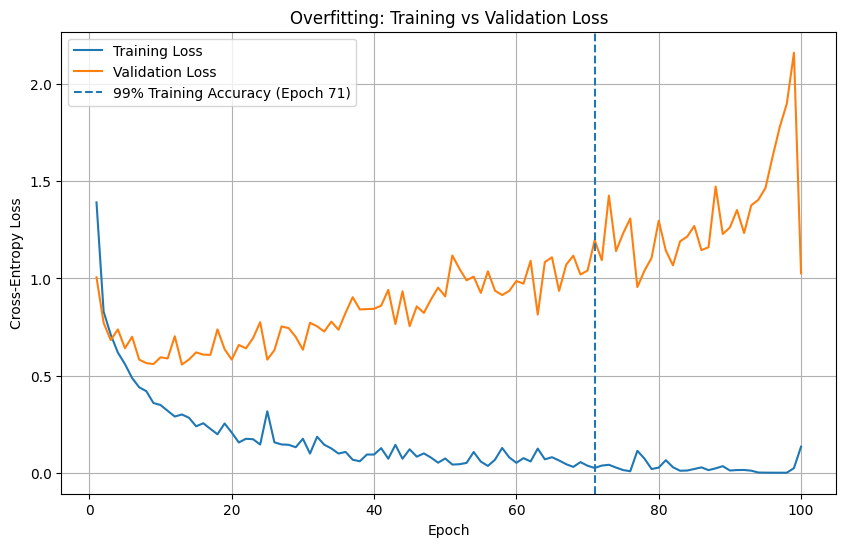

In [77]:
# ============================================================
# PART 5: Plot Training vs Validation Loss
# ============================================================

plt.figure(figsize=(10, 6))

plt.plot(
    range(1, len(overfit_train_losses) + 1),
    overfit_train_losses,
    label="Training Loss"
)

plt.plot(
    range(1, len(overfit_val_losses) + 1),
    overfit_val_losses,
    label="Validation Loss"
)

# Mark the epoch where training accuracy first reached 99%
if epoch_99 is not None:
    plt.axvline(
        x=epoch_99,
        linestyle="--",
        label=f"99% Training Accuracy (Epoch {epoch_99})"
    )

plt.xlabel("Epoch")
plt.ylabel("Cross-Entropy Loss")
plt.title("Overfitting: Training vs Validation Loss")
plt.legend()
plt.grid(True)
plt.show()

Part 5 : Step 7: Plot Training vs Validation Accuracy

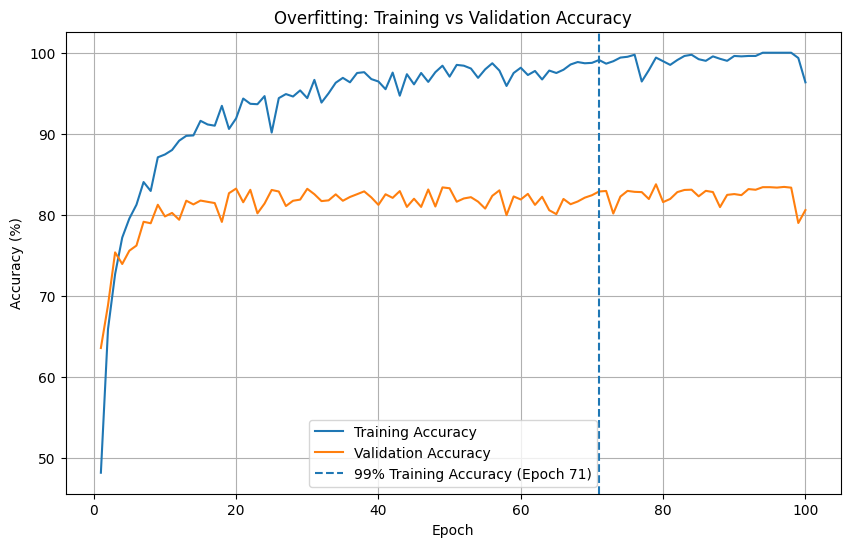

In [78]:
# ============================================================
# PART 5: Plot Training vs Validation Accuracy
# ============================================================

plt.figure(figsize=(10, 6))

plt.plot(
    range(1, len(overfit_train_accuracies) + 1),
    overfit_train_accuracies,
    label="Training Accuracy"
)

plt.plot(
    range(1, len(overfit_val_accuracies) + 1),
    overfit_val_accuracies,
    label="Validation Accuracy"
)

# Mark the epoch where training accuracy first reached 99%
if epoch_99 is not None:
    plt.axvline(
        x=epoch_99,
        linestyle="--",
        label=f"99% Training Accuracy (Epoch {epoch_99})"
    )

plt.xlabel("Epoch")
plt.ylabel("Accuracy (%)")
plt.title("Overfitting: Training vs Validation Accuracy")
plt.legend()
plt.grid(True)
plt.show()

Part 5 : Step 8: Calculate the Generalization Gap

In [79]:
# ============================================================
# PART 5: Calculate Generalization Gap
# ============================================================

final_train_accuracy = overfit_train_accuracies[-1]
final_val_accuracy = overfit_val_accuracies[-1]

generalization_gap = (
    final_train_accuracy - final_val_accuracy
)

print("Final Overfitting Results")
print("=" * 60)

print(
    f"Training Accuracy:   {final_train_accuracy:.2f}%"
)

print(
    f"Validation Accuracy: {final_val_accuracy:.2f}%"
)

print(
    f"Generalization Gap:  {generalization_gap:.2f} percentage points"
)

# Find the epoch with the largest accuracy gap
accuracy_gaps = [
    train_acc - val_acc
    for train_acc, val_acc
    in zip(
        overfit_train_accuracies,
        overfit_val_accuracies
    )
]

max_gap_epoch = np.argmax(accuracy_gaps) + 1
max_gap = accuracy_gaps[max_gap_epoch - 1]

print("\nLargest Observed Gap")
print("=" * 60)

print(f"Epoch: {max_gap_epoch}")
print(f"Maximum Gap: {max_gap:.2f} percentage points")

Final Overfitting Results
Training Accuracy:   96.35%
Validation Accuracy: 80.59%
Generalization Gap:  15.76 percentage points

Largest Observed Gap
Epoch: 99
Maximum Gap: 20.35 percentage points


Part 5 : Step 9: Diagnose Bias vs Variance

In [80]:
# ============================================================
# PART 5: Bias-Variance Diagnosis
# ============================================================

print("Bias-Variance Diagnosis")
print("=" * 60)

print(f"Final Training Accuracy:   {final_train_accuracy:.2f}%")
print(f"Final Validation Accuracy: {final_val_accuracy:.2f}%")
print(f"Generalization Gap:        {generalization_gap:.2f} pp")

print("\nDiagnosis:")

if final_train_accuracy >= 99 and generalization_gap >= 5:
    print(
        "HIGH VARIANCE / OVERFITTING: "
        "The model fits the training data extremely well, "
        "but its validation performance is considerably lower."
    )

elif final_train_accuracy < 90 and final_val_accuracy < 90:
    print(
        "HIGH BIAS / UNDERFITTING: "
        "Both training and validation accuracy are relatively low."
    )

elif generalization_gap >= 5:
    print(
        "HIGH VARIANCE / OVERFITTING: "
        "There is a substantial gap between training and validation accuracy."
    )

else:
    print(
        "MIXED OR MODERATE BIAS-VARIANCE: "
        "The training-validation gap is relatively small."
    )

Bias-Variance Diagnosis
Final Training Accuracy:   96.35%
Final Validation Accuracy: 80.59%
Generalization Gap:        15.76 pp

Diagnosis:
HIGH VARIANCE / OVERFITTING: There is a substantial gap between training and validation accuracy.


Part 5 : Step 10: Find the Separation Epoch

In [81]:
# ============================================================
# PART 5: Find the Separation Epoch
# ============================================================

# Find the epoch with the minimum validation loss
best_val_loss_epoch = np.argmin(overfit_val_losses) + 1
best_val_loss = overfit_val_losses[best_val_loss_epoch - 1]

# Find the first epoch after the minimum validation loss
# where validation loss becomes higher than the previous epoch
separation_epoch = None

for i in range(best_val_loss_epoch, len(overfit_val_losses)):
    if overfit_val_losses[i] > overfit_val_losses[i - 1]:
        separation_epoch = i + 1
        break

print("Overfitting Separation Analysis")
print("=" * 60)

print(
    f"Minimum Validation Loss: {best_val_loss:.4f}"
)

print(
    f"Epoch of Minimum Validation Loss: "
    f"{best_val_loss_epoch}"
)

if separation_epoch is not None:
    print(
        f"Separation Epoch: {separation_epoch}"
    )
    print(
        "After this point, validation loss starts increasing "
        "while the model continues fitting the training data."
    )
else:
    print(
        "A clear separation epoch was not detected."
    )

Overfitting Separation Analysis
Minimum Validation Loss: 0.5571
Epoch of Minimum Validation Loss: 13
Separation Epoch: 14
After this point, validation loss starts increasing while the model continues fitting the training data.


Part 5 : Step 11: Final Overfitting Summary

In [82]:
# ============================================================
# PART 5: Final Overfitting Summary
# ============================================================

print("=" * 70)
print("PART 5 — FORCING OVERFITTING: FINAL SUMMARY")
print("=" * 70)

print(f"Training Set Size:              {len(X_overfit)}")
print(f"Hidden Layers:                  4")
print(f"Units per Hidden Layer:         512")
print(f"Maximum Epochs:                 {OVERFIT_EPOCHS}")

print("\nPerformance")
print("-" * 70)

print(
    f"Final Training Accuracy:        "
    f"{final_train_accuracy:.2f}%"
)

print(
    f"Final Validation Accuracy:      "
    f"{final_val_accuracy:.2f}%"
)

print(
    f"Generalization Gap:             "
    f"{generalization_gap:.2f} percentage points"
)

if epoch_99 is not None:
    print(
        f"Epoch Training Accuracy >=99%: "
        f"{epoch_99}"
    )
else:
    print(
        "Epoch Training Accuracy >=99%: Not Reached"
    )

if separation_epoch is not None:
    print(
        f"Separation Epoch:               "
        f"{separation_epoch}"
    )
else:
    print(
        "Separation Epoch:               Not Clearly Detected"
    )

print("\nDiagnosis")
print("-" * 70)

if final_train_accuracy >= 99 and generalization_gap >= 5:
    print(
        "The model shows high variance (overfitting). "
        "Its very high training accuracy and substantially "
        "lower validation accuracy indicate poor generalization."
    )
elif final_train_accuracy < 90 and final_val_accuracy < 90:
    print(
        "The model shows high bias (underfitting), "
        "because both training and validation accuracy are low."
    )
else:
    print(
        "The model shows a moderate or mixed "
        "bias-variance behavior."
    )

print("=" * 70)

PART 5 — FORCING OVERFITTING: FINAL SUMMARY
Training Set Size:              2000
Hidden Layers:                  4
Units per Hidden Layer:         512
Maximum Epochs:                 100

Performance
----------------------------------------------------------------------
Final Training Accuracy:        96.35%
Final Validation Accuracy:      80.59%
Generalization Gap:             15.76 percentage points
Epoch Training Accuracy >=99%: 71
Separation Epoch:               14

Diagnosis
----------------------------------------------------------------------
The model shows a moderate or mixed bias-variance behavior.


Part 6 : Step 1: Prepare the Regularization Experiment

In [83]:
# ============================================================
# PART 6: REGULARIZATION
# Step 1: Prepare Regularization Experiment
# ============================================================

# Save the overfitting baseline results
regularization_baseline = {
    "Train Accuracy (%)": final_train_accuracy,
    "Validation Accuracy (%)": final_val_accuracy,
    "Generalization Gap (pp)": generalization_gap
}

# Regularization training settings
REG_EPOCHS = 30
REG_BATCH_SIZE = 64
REG_LR = 0.001

print("=" * 70)
print("PART 6 — REGULARIZATION")
print("=" * 70)

print("\nStarting Overfit Baseline:")
print(
    f"Training Accuracy:   "
    f"{final_train_accuracy:.2f}%"
)
print(
    f"Validation Accuracy: "
    f"{final_val_accuracy:.2f}%"
)
print(
    f"Generalization Gap:  "
    f"{generalization_gap:.2f} pp"
)

print("\nRegularization Settings:")
print(f"Epochs:               {REG_EPOCHS}")
print(f"Batch Size:           {REG_BATCH_SIZE}")
print(f"Learning Rate:        {REG_LR}")
print("\nReady for regularization experiments.")

PART 6 — REGULARIZATION

Starting Overfit Baseline:
Training Accuracy:   96.35%
Validation Accuracy: 80.59%
Generalization Gap:  15.76 pp

Regularization Settings:
Epochs:               30
Batch Size:           64
Learning Rate:        0.001

Ready for regularization experiments.


Part 6 : Step 2: L2 Regularization Function

In [84]:
# ============================================================
# PART 6: L2 REGULARIZATION
# Step 2: Create L2 Training Function
# ============================================================

def train_with_l2(l2_lambda):
    """
    Train the same overfit architecture using L2 regularization.

    l2_lambda:
        Strength of the L2 regularization penalty.
    """

    # Fresh model for a fair comparison
    model = OverfitNetwork()

    # Cross-entropy classification loss
    criterion = nn.CrossEntropyLoss()

    # Adam optimizer with L2 regularization through weight_decay
    optimizer = optim.Adam(
        model.parameters(),
        lr=REG_LR,
        weight_decay=l2_lambda
    )

    train_losses = []
    val_losses = []

    train_accuracies = []
    val_accuracies = []

    for epoch in range(REG_EPOCHS):

        # -------------------------
        # Training
        # -------------------------
        model.train()

        total_train_loss = 0
        correct_train = 0
        total_train = 0

        for X_batch, y_batch in overfit_loader:

            optimizer.zero_grad()

            outputs = model(X_batch)

            loss = criterion(outputs, y_batch)

            loss.backward()

            optimizer.step()

            total_train_loss += (
                loss.item() * X_batch.size(0)
            )

            predictions = torch.argmax(outputs, dim=1)

            correct_train += (
                predictions == y_batch
            ).sum().item()

            total_train += y_batch.size(0)

        train_loss = total_train_loss / total_train
        train_accuracy = (correct_train / total_train) * 100

        # -------------------------
        # Validation
        # -------------------------
        model.eval()

        total_val_loss = 0
        correct_val = 0
        total_val = 0

        with torch.no_grad():

            for X_batch, y_batch in val_loader:

                outputs = model(X_batch)

                loss = criterion(outputs, y_batch)

                total_val_loss += (
                    loss.item() * X_batch.size(0)
                )

                predictions = torch.argmax(
                    outputs,
                    dim=1
                )

                correct_val += (
                    predictions == y_batch
                ).sum().item()

                total_val += y_batch.size(0)

        val_loss = total_val_loss / total_val
        val_accuracy = (correct_val / total_val) * 100

        # Store results
        train_losses.append(train_loss)
        val_losses.append(val_loss)

        train_accuracies.append(train_accuracy)
        val_accuracies.append(val_accuracy)

    return {
        "model": model,
        "train_losses": train_losses,
        "val_losses": val_losses,
        "train_accuracies": train_accuracies,
        "val_accuracies": val_accuracies
    }


print("L2 regularization training function created successfully.")

L2 regularization training function created successfully.


Part 6 : Step 3: Test Three L2 Regularization Strengths

In [85]:
# ============================================================
# PART 6: L2 REGULARIZATION
# Step 3: Test Multiple L2 Strengths
# ============================================================

# Three different L2 regularization strengths
l2_lambdas = [0.0001, 0.001, 0.01]

l2_results = {}

for l2_lambda in l2_lambdas:

    print("\n" + "=" * 60)
    print(f"Training with L2 Lambda = {l2_lambda}")
    print("=" * 60)

    result = train_with_l2(l2_lambda)

    l2_results[l2_lambda] = result

    final_train_acc = result["train_accuracies"][-1]
    final_val_acc = result["val_accuracies"][-1]

    print(
        f"Final Training Accuracy:   {final_train_acc:.2f}%"
    )

    print(
        f"Final Validation Accuracy: {final_val_acc:.2f}%"
    )

    print(
        f"Generalization Gap:        "
        f"{final_train_acc - final_val_acc:.2f} pp"
    )

print("\nAll L2 experiments completed.")


Training with L2 Lambda = 0.0001
Final Training Accuracy:   92.50%
Final Validation Accuracy: 82.12%
Generalization Gap:        10.38 pp

Training with L2 Lambda = 0.001
Final Training Accuracy:   94.80%
Final Validation Accuracy: 81.58%
Generalization Gap:        13.22 pp

Training with L2 Lambda = 0.01
Final Training Accuracy:   83.35%
Final Validation Accuracy: 77.32%
Generalization Gap:        6.03 pp

All L2 experiments completed.


Part 6 : Step 4: Create L2 Results Table

In [86]:
# ============================================================
# PART 6: L2 REGULARIZATION
# Step 4: Create Results Table
# ============================================================

l2_table_data = []

for l2_lambda, result in l2_results.items():

    train_acc = result["train_accuracies"][-1]
    val_acc = result["val_accuracies"][-1]
    gap = train_acc - val_acc

    l2_table_data.append({
        "Method": "L2 Regularization",
        "Setting (Lambda)": l2_lambda,
        "Train Accuracy (%)": train_acc,
        "Validation Accuracy (%)": val_acc,
        "Generalization Gap (pp)": gap
    })

l2_table = pd.DataFrame(l2_table_data)

# Round values for readability
l2_table["Train Accuracy (%)"] = (
    l2_table["Train Accuracy (%)"].round(2)
)

l2_table["Validation Accuracy (%)"] = (
    l2_table["Validation Accuracy (%)"].round(2)
)

l2_table["Generalization Gap (pp)"] = (
    l2_table["Generalization Gap (pp)"].round(2)
)

display(l2_table)

,Method,Setting (Lambda),Train Accuracy (%),Validation Accuracy (%),Generalization Gap (pp)
0,L2 Regularization,0.0001,92.50,82.12,10.38
1,L2 Regularization,0.0010,94.80,81.58,13.22
2,L2 Regularization,0.0100,83.35,77.32,6.03


Part 6 : Step 5: L1 Regularization Function

In [87]:
# ============================================================
# PART 6: L1 REGULARIZATION
# Step 5: Create L1 Training Function
# ============================================================

def train_with_l1(l1_lambda):
    """
    Train the overfit network with L1 regularization.

    L1 penalty = lambda * sum(|weights|)
    """

    # Fresh model
    model = OverfitNetwork()

    criterion = nn.CrossEntropyLoss()

    optimizer = optim.Adam(
        model.parameters(),
        lr=REG_LR
    )

    train_losses = []
    val_losses = []

    train_accuracies = []
    val_accuracies = []

    for epoch in range(REG_EPOCHS):

        # -------------------------
        # Training
        # -------------------------
        model.train()

        total_train_loss = 0
        correct_train = 0
        total_train = 0

        for X_batch, y_batch in overfit_loader:

            optimizer.zero_grad()

            outputs = model(X_batch)

            # Cross-entropy loss
            ce_loss = criterion(outputs, y_batch)

            # Calculate L1 penalty on weights only
            l1_penalty = 0.0

            for parameter in model.parameters():
                l1_penalty += torch.sum(torch.abs(parameter))

            # Total loss = CE + L1 penalty
            loss = ce_loss + l1_lambda * l1_penalty

            loss.backward()

            optimizer.step()

            total_train_loss += (
                ce_loss.item() * X_batch.size(0)
            )

            predictions = torch.argmax(outputs, dim=1)

            correct_train += (
                predictions == y_batch
            ).sum().item()

            total_train += y_batch.size(0)

        train_loss = total_train_loss / total_train
        train_accuracy = (correct_train / total_train) * 100

        # -------------------------
        # Validation
        # -------------------------
        model.eval()

        total_val_loss = 0
        correct_val = 0
        total_val = 0

        with torch.no_grad():

            for X_batch, y_batch in val_loader:

                outputs = model(X_batch)

                loss = criterion(outputs, y_batch)

                total_val_loss += (
                    loss.item() * X_batch.size(0)
                )

                predictions = torch.argmax(
                    outputs,
                    dim=1
                )

                correct_val += (
                    predictions == y_batch
                ).sum().item()

                total_val += y_batch.size(0)

        val_loss = total_val_loss / total_val
        val_accuracy = (correct_val / total_val) * 100

        train_losses.append(train_loss)
        val_losses.append(val_loss)

        train_accuracies.append(train_accuracy)
        val_accuracies.append(val_accuracy)

    return {
        "model": model,
        "train_losses": train_losses,
        "val_losses": val_losses,
        "train_accuracies": train_accuracies,
        "val_accuracies": val_accuracies
    }


print("L1 regularization training function created successfully.")

L1 regularization training function created successfully.


Part 6 : Step 6: Test L1 Regularization

In [88]:
# ============================================================
# PART 6: L1 REGULARIZATION
# Step 6: Test Multiple L1 Strengths
# ============================================================

# Three L1 regularization strengths
l1_lambdas = [0.00001, 0.00005, 0.0001]

l1_results = {}

for l1_lambda in l1_lambdas:

    print("\n" + "=" * 60)
    print(f"Training with L1 Lambda = {l1_lambda}")
    print("=" * 60)

    result = train_with_l1(l1_lambda)

    l1_results[l1_lambda] = result

    final_train_acc = result["train_accuracies"][-1]
    final_val_acc = result["val_accuracies"][-1]

    print(
        f"Final Training Accuracy:   {final_train_acc:.2f}%"
    )

    print(
        f"Final Validation Accuracy: {final_val_acc:.2f}%"
    )

    print(
        f"Generalization Gap:        "
        f"{final_train_acc - final_val_acc:.2f} pp"
    )

print("\nAll L1 experiments completed.")


Training with L1 Lambda = 1e-05
Final Training Accuracy:   95.20%
Final Validation Accuracy: 78.94%
Generalization Gap:        16.26 pp

Training with L1 Lambda = 5e-05
Final Training Accuracy:   91.65%
Final Validation Accuracy: 79.25%
Generalization Gap:        12.40 pp

Training with L1 Lambda = 0.0001
Final Training Accuracy:   90.40%
Final Validation Accuracy: 81.23%
Generalization Gap:        9.17 pp

All L1 experiments completed.


Part 6 : Step 7: Create L1 Results Table

In [89]:
# ============================================================
# PART 6: L1 REGULARIZATION
# Step 7: Results + Sparse Weight Percentage
# ============================================================

l1_table_data = []

for l1_lambda, result in l1_results.items():

    model = result["model"]

    train_acc = result["train_accuracies"][-1]
    val_acc = result["val_accuracies"][-1]
    gap = train_acc - val_acc

    # Collect only weight parameters (exclude biases)
    weight_values = []

    for name, parameter in model.named_parameters():
        if "weight" in name:
            weight_values.append(
                parameter.detach().cpu().numpy().flatten()
            )

    # Combine all weights into one array
    all_weights = np.concatenate(weight_values)

    # Percentage of weights with absolute value below 1e-3
    small_weights_percentage = (
        np.mean(np.abs(all_weights) < 1e-3) * 100
    )

    l1_table_data.append({
        "Method": "L1 Regularization",
        "Setting (Lambda)": l1_lambda,
        "Train Accuracy (%)": train_acc,
        "Validation Accuracy (%)": val_acc,
        "Generalization Gap (pp)": gap,
        "Weights |w| < 1e-3 (%)": small_weights_percentage
    })

l1_table = pd.DataFrame(l1_table_data)

# Round values for readability
l1_table["Train Accuracy (%)"] = (
    l1_table["Train Accuracy (%)"].round(2)
)

l1_table["Validation Accuracy (%)"] = (
    l1_table["Validation Accuracy (%)"].round(2)
)

l1_table["Generalization Gap (pp)"] = (
    l1_table["Generalization Gap (pp)"].round(2)
)

l1_table["Weights |w| < 1e-3 (%)"] = (
    l1_table["Weights |w| < 1e-3 (%)"].round(2)
)

display(l1_table)

,Method,Setting (Lambda),Train Accuracy (%),Validation Accuracy (%),Generalization Gap (pp),Weights |w| < 1e-3 (%)
0,L1 Regularization,0.00001,95.20,78.94,16.26,43.14
1,L1 Regularization,0.00005,91.65,79.25,12.40,69.97
2,L1 Regularization,0.00010,90.40,81.23,9.17,84.89


Part 6 : Step 8: Dropout Regularization Function

In [90]:
# ============================================================
# PART 6: DROPOUT REGULARIZATION
# Step 8: Create Dropout Training Function
# ============================================================

def train_with_dropout(dropout_rate):
    """
    Train the overfit network with dropout regularization.
    """

    # Same architecture, with dropout added after each ReLU
    model = nn.Sequential(
        nn.Linear(784, 512),
        nn.ReLU(),
        nn.Dropout(dropout_rate),

        nn.Linear(512, 512),
        nn.ReLU(),
        nn.Dropout(dropout_rate),

        nn.Linear(512, 512),
        nn.ReLU(),
        nn.Dropout(dropout_rate),

        nn.Linear(512, 512),
        nn.ReLU(),
        nn.Dropout(dropout_rate),

        nn.Linear(512, 10)
    )

    criterion = nn.CrossEntropyLoss()

    optimizer = optim.Adam(
        model.parameters(),
        lr=REG_LR
    )

    train_losses = []
    val_losses = []

    train_accuracies = []
    val_accuracies = []

    for epoch in range(REG_EPOCHS):

        # -------------------------
        # Training
        # -------------------------
        model.train()

        total_train_loss = 0
        correct_train = 0
        total_train = 0

        for X_batch, y_batch in overfit_loader:

            optimizer.zero_grad()

            outputs = model(X_batch)

            loss = criterion(outputs, y_batch)

            loss.backward()

            optimizer.step()

            total_train_loss += (
                loss.item() * X_batch.size(0)
            )

            predictions = torch.argmax(
                outputs,
                dim=1
            )

            correct_train += (
                predictions == y_batch
            ).sum().item()

            total_train += y_batch.size(0)

        train_loss = total_train_loss / total_train
        train_accuracy = (correct_train / total_train) * 100

        # -------------------------
        # Validation
        # -------------------------
        model.eval()

        total_val_loss = 0
        correct_val = 0
        total_val = 0

        with torch.no_grad():

            for X_batch, y_batch in val_loader:

                outputs = model(X_batch)

                loss = criterion(outputs, y_batch)

                total_val_loss += (
                    loss.item() * X_batch.size(0)
                )

                predictions = torch.argmax(
                    outputs,
                    dim=1
                )

                correct_val += (
                    predictions == y_batch
                ).sum().item()

                total_val += y_batch.size(0)

        val_loss = total_val_loss / total_val
        val_accuracy = (correct_val / total_val) * 100

        train_losses.append(train_loss)
        val_losses.append(val_loss)

        train_accuracies.append(train_accuracy)
        val_accuracies.append(val_accuracy)

    return {
        "model": model,
        "train_losses": train_losses,
        "val_losses": val_losses,
        "train_accuracies": train_accuracies,
        "val_accuracies": val_accuracies
    }


print("Dropout training function created successfully.")

Dropout training function created successfully.


Part 6 : Step 9: Test Three Dropout Rates

In [91]:
# ============================================================
# PART 6: DROPOUT REGULARIZATION
# Step 9: Test Multiple Dropout Rates
# ============================================================

# Three dropout strengths
dropout_rates = [0.2, 0.4, 0.6]

dropout_results = {}

for dropout_rate in dropout_rates:

    print("\n" + "=" * 60)
    print(f"Training with Dropout Rate = {dropout_rate}")
    print("=" * 60)

    result = train_with_dropout(dropout_rate)

    dropout_results[dropout_rate] = result

    final_train_acc = result["train_accuracies"][-1]
    final_val_acc = result["val_accuracies"][-1]

    print(
        f"Final Training Accuracy:   {final_train_acc:.2f}%"
    )

    print(
        f"Final Validation Accuracy: {final_val_acc:.2f}%"
    )

    print(
        f"Generalization Gap:        "
        f"{final_train_acc - final_val_acc:.2f} pp"
    )

print("\nAll Dropout experiments completed.")


Training with Dropout Rate = 0.2
Final Training Accuracy:   92.85%
Final Validation Accuracy: 81.23%
Generalization Gap:        11.62 pp

Training with Dropout Rate = 0.4
Final Training Accuracy:   88.75%
Final Validation Accuracy: 83.03%
Generalization Gap:        5.72 pp

Training with Dropout Rate = 0.6
Final Training Accuracy:   82.05%
Final Validation Accuracy: 81.78%
Generalization Gap:        0.27 pp

All Dropout experiments completed.


Part 6 : Step 10: Create Dropout Results Table

In [92]:
# ============================================================
# PART 6: DROPOUT REGULARIZATION
# Step 10: Create Results Table
# ============================================================

dropout_table_data = []

for dropout_rate, result in dropout_results.items():

    train_acc = result["train_accuracies"][-1]
    val_acc = result["val_accuracies"][-1]
    gap = train_acc - val_acc

    dropout_table_data.append({
        "Method": "Dropout",
        "Setting (Rate)": dropout_rate,
        "Train Accuracy (%)": train_acc,
        "Validation Accuracy (%)": val_acc,
        "Generalization Gap (pp)": gap
    })

dropout_table = pd.DataFrame(dropout_table_data)

# Round values for readability
dropout_table["Train Accuracy (%)"] = (
    dropout_table["Train Accuracy (%)"].round(2)
)

dropout_table["Validation Accuracy (%)"] = (
    dropout_table["Validation Accuracy (%)"].round(2)
)

dropout_table["Generalization Gap (pp)"] = (
    dropout_table["Generalization Gap (pp)"].round(2)
)

display(dropout_table)

,Method,Setting (Rate),Train Accuracy (%),Validation Accuracy (%),Generalization Gap (pp)
0,Dropout,0.2,92.85,81.23,11.62
1,Dropout,0.4,88.75,83.02,5.72
2,Dropout,0.6,82.05,81.78,0.27


Part 6 : Step 11: Batch Normalization

In [93]:
# ============================================================
# PART 6: BATCH NORMALIZATION
# Step 11: Create BatchNorm Training Function
# ============================================================

def train_with_batchnorm():
    """
    Train the overfit network using Batch Normalization.
    """

    # Same high-capacity architecture,
    # with BatchNorm after each linear layer.
    model = nn.Sequential(
        nn.Linear(784, 512),
        nn.BatchNorm1d(512),
        nn.ReLU(),

        nn.Linear(512, 512),
        nn.BatchNorm1d(512),
        nn.ReLU(),

        nn.Linear(512, 512),
        nn.BatchNorm1d(512),
        nn.ReLU(),

        nn.Linear(512, 512),
        nn.BatchNorm1d(512),
        nn.ReLU(),

        nn.Linear(512, 10)
    )

    criterion = nn.CrossEntropyLoss()

    optimizer = optim.Adam(
        model.parameters(),
        lr=REG_LR
    )

    train_losses = []
    val_losses = []

    train_accuracies = []
    val_accuracies = []

    for epoch in range(REG_EPOCHS):

        # -------------------------
        # Training
        # -------------------------
        model.train()

        total_train_loss = 0
        correct_train = 0
        total_train = 0

        for X_batch, y_batch in overfit_loader:

            optimizer.zero_grad()

            outputs = model(X_batch)

            loss = criterion(outputs, y_batch)

            loss.backward()

            optimizer.step()

            total_train_loss += (
                loss.item() * X_batch.size(0)
            )

            predictions = torch.argmax(
                outputs,
                dim=1
            )

            correct_train += (
                predictions == y_batch
            ).sum().item()

            total_train += y_batch.size(0)

        train_loss = total_train_loss / total_train
        train_accuracy = (correct_train / total_train) * 100

        # -------------------------
        # Validation
        # -------------------------
        model.eval()

        total_val_loss = 0
        correct_val = 0
        total_val = 0

        with torch.no_grad():

            for X_batch, y_batch in val_loader:

                outputs = model(X_batch)

                loss = criterion(outputs, y_batch)

                total_val_loss += (
                    loss.item() * X_batch.size(0)
                )

                predictions = torch.argmax(
                    outputs,
                    dim=1
                )

                correct_val += (
                    predictions == y_batch
                ).sum().item()

                total_val += y_batch.size(0)

        val_loss = total_val_loss / total_val
        val_accuracy = (correct_val / total_val) * 100

        train_losses.append(train_loss)
        val_losses.append(val_loss)

        train_accuracies.append(train_accuracy)
        val_accuracies.append(val_accuracy)

    return {
        "model": model,
        "train_losses": train_losses,
        "val_losses": val_losses,
        "train_accuracies": train_accuracies,
        "val_accuracies": val_accuracies
    }


print("Batch Normalization training function created successfully.")

Batch Normalization training function created successfully.


Part 6 : Step 12: Run Batch Normalization Experiment

In [94]:
# ============================================================
# PART 6: BATCH NORMALIZATION
# Step 12: Run BatchNorm Experiment
# ============================================================

print("=" * 60)
print("Training with Batch Normalization")
print("=" * 60)

batchnorm_result = train_with_batchnorm()

# Final results
batchnorm_train_acc = (
    batchnorm_result["train_accuracies"][-1]
)

batchnorm_val_acc = (
    batchnorm_result["val_accuracies"][-1]
)

batchnorm_gap = (
    batchnorm_train_acc - batchnorm_val_acc
)

print(
    f"Final Training Accuracy:   "
    f"{batchnorm_train_acc:.2f}%"
)

print(
    f"Final Validation Accuracy: "
    f"{batchnorm_val_acc:.2f}%"
)

print(
    f"Generalization Gap:        "
    f"{batchnorm_gap:.2f} pp"
)

print("\nBatch Normalization experiment completed.")

Training with Batch Normalization
Final Training Accuracy:   98.15%
Final Validation Accuracy: 79.66%
Generalization Gap:        18.49 pp

Batch Normalization experiment completed.


Part 6 : Step 13: Early Stopping Function

In [95]:
# ============================================================
# PART 6: EARLY STOPPING
# Step 13: Create Early Stopping Training Function
# ============================================================

def train_with_early_stopping(patience=5):
    """
    Train the overfit network with early stopping.

    Training stops when validation loss does not improve
    for 'patience' consecutive epochs.
    """

    # Fresh overfit model
    model = OverfitNetwork()

    criterion = nn.CrossEntropyLoss()

    optimizer = optim.Adam(
        model.parameters(),
        lr=REG_LR
    )

    train_losses = []
    val_losses = []

    train_accuracies = []
    val_accuracies = []

    # Best validation loss seen so far
    best_val_loss = float("inf")

    # Store the best model parameters
    best_model_state = None

    # Number of consecutive epochs without improvement
    epochs_without_improvement = 0

    # Maximum epochs
    EARLY_STOP_MAX_EPOCHS = 50

    for epoch in range(EARLY_STOP_MAX_EPOCHS):

        # -------------------------
        # Training
        # -------------------------
        model.train()

        total_train_loss = 0
        correct_train = 0
        total_train = 0

        for X_batch, y_batch in overfit_loader:

            optimizer.zero_grad()

            outputs = model(X_batch)

            loss = criterion(outputs, y_batch)

            loss.backward()

            optimizer.step()

            total_train_loss += (
                loss.item() * X_batch.size(0)
            )

            predictions = torch.argmax(
                outputs,
                dim=1
            )

            correct_train += (
                predictions == y_batch
            ).sum().item()

            total_train += y_batch.size(0)

        train_loss = total_train_loss / total_train
        train_accuracy = (correct_train / total_train) * 100

        # -------------------------
        # Validation
        # -------------------------
        model.eval()

        total_val_loss = 0
        correct_val = 0
        total_val = 0

        with torch.no_grad():

            for X_batch, y_batch in val_loader:

                outputs = model(X_batch)

                loss = criterion(outputs, y_batch)

                total_val_loss += (
                    loss.item() * X_batch.size(0)
                )

                predictions = torch.argmax(
                    outputs,
                    dim=1
                )

                correct_val += (
                    predictions == y_batch
                ).sum().item()

                total_val += y_batch.size(0)

        val_loss = total_val_loss / total_val
        val_accuracy = (correct_val / total_val) * 100

        # Store history
        train_losses.append(train_loss)
        val_losses.append(val_loss)

        train_accuracies.append(train_accuracy)
        val_accuracies.append(val_accuracy)

        # -------------------------
        # Early stopping check
        # -------------------------

        if val_loss < best_val_loss:

            best_val_loss = val_loss
            epochs_without_improvement = 0

            # Save best model
            best_model_state = {
                key: value.cpu().clone()
                for key, value in model.state_dict().items()
            }

        else:

            epochs_without_improvement += 1

        # Stop if patience is reached
        if epochs_without_improvement >= patience:

            print(
                f"Early stopping triggered at "
                f"epoch {epoch + 1}."
            )

            break

    # Restore the best model
    if best_model_state is not None:
        model.load_state_dict(best_model_state)

    return {
        "model": model,
        "train_losses": train_losses,
        "val_losses": val_losses,
        "train_accuracies": train_accuracies,
        "val_accuracies": val_accuracies,
        "stop_epoch": len(train_losses),
        "best_val_loss": best_val_loss
    }


print("Early stopping training function created successfully.")

Early stopping training function created successfully.


Part 6 : Step 14: Run Early Stopping Experiment

In [96]:
# ============================================================
# PART 6: EARLY STOPPING
# Step 14: Run Early Stopping Experiment
# ============================================================

EARLY_STOP_PATIENCE = 5

print("=" * 60)
print("Training with Early Stopping")
print("=" * 60)
print(f"Patience: {EARLY_STOP_PATIENCE}")

early_stopping_result = train_with_early_stopping(
    patience=EARLY_STOP_PATIENCE
)

# Final recorded performance
early_train_acc = (
    early_stopping_result["train_accuracies"][-1]
)

early_val_acc = (
    early_stopping_result["val_accuracies"][-1]
)

early_gap = early_train_acc - early_val_acc

stop_epoch = early_stopping_result["stop_epoch"]

best_val_loss_early = (
    early_stopping_result["best_val_loss"]
)

print("\nEarly Stopping Results")
print("-" * 60)

print(
    f"Training Stop Epoch:       {stop_epoch}"
)

print(
    f"Best Validation Loss:      "
    f"{best_val_loss_early:.4f}"
)

print(
    f"Final Training Accuracy:   "
    f"{early_train_acc:.2f}%"
)

print(
    f"Final Validation Accuracy: "
    f"{early_val_acc:.2f}%"
)

print(
    f"Generalization Gap:        "
    f"{early_gap:.2f} pp"
)

Training with Early Stopping
Patience: 5
Early stopping triggered at epoch 12.

Early Stopping Results
------------------------------------------------------------
Training Stop Epoch:       12
Best Validation Loss:      0.5358
Final Training Accuracy:   88.10%
Final Validation Accuracy: 81.42%
Generalization Gap:        6.68 pp


Part 6  Data Augmentation

Step 15: Train with Random Horizontal Flip + Small Rotation

In [97]:
# ============================================================
# PART 6: DATA AUGMENTATION
# Step 15: Random Horizontal Flip + Small Rotation
# ============================================================

import torch
from torch.utils.data import Dataset, DataLoader
from torchvision import transforms

# ------------------------------------------------------------
# Custom Dataset for applying augmentation
# ------------------------------------------------------------

class AugmentedFashionDataset(Dataset):
    def __init__(self, X, y):
        # Convert flattened 784 pixels back to 28x28 images
        self.X = torch.tensor(
            X.reshape(-1, 1, 28, 28),
            dtype=torch.float32
        )
        self.y = torch.tensor(y, dtype=torch.long)

        # Required augmentations:
        # 1. Random horizontal flip
        # 2. Small random rotation
        self.transform = transforms.Compose([
            transforms.RandomHorizontalFlip(p=0.5),
            transforms.RandomRotation(degrees=10)
        ])

    def __len__(self):
        return len(self.y)

    def __getitem__(self, index):
        image = self.X[index]
        label = self.y[index]

        # Apply augmentation
        image = self.transform(image)

        # Flatten back to 784 features
        image = image.view(-1)

        return image, label


# ------------------------------------------------------------
# Create augmented training dataset
# ------------------------------------------------------------

augmented_dataset = AugmentedFashionDataset(
    X_overfit,
    y_overfit
)

augmented_loader = DataLoader(
    augmented_dataset,
    batch_size=REG_BATCH_SIZE,
    shuffle=True
)


# ------------------------------------------------------------
# Train augmented model
# ------------------------------------------------------------

augmentation_model = OverfitNetwork()

criterion = nn.CrossEntropyLoss()

optimizer = optim.Adam(
    augmentation_model.parameters(),
    lr=REG_LR
)

augmentation_train_losses = []
augmentation_val_losses = []

augmentation_train_accuracies = []
augmentation_val_accuracies = []


for epoch in range(REG_EPOCHS):

    # -------------------------
    # Training
    # -------------------------
    augmentation_model.train()

    running_loss = 0.0
    correct = 0
    total = 0

    for X_batch, y_batch in augmented_loader:

        optimizer.zero_grad()

        outputs = augmentation_model(X_batch)

        loss = criterion(outputs, y_batch)

        loss.backward()
        optimizer.step()

        running_loss += loss.item() * X_batch.size(0)

        predictions = torch.argmax(outputs, dim=1)

        correct += (predictions == y_batch).sum().item()
        total += y_batch.size(0)

    train_loss = running_loss / total
    train_accuracy = (correct / total) * 100


    # -------------------------
    # Validation
    # -------------------------
    augmentation_model.eval()

    val_loss_total = 0.0
    val_correct = 0
    val_total = 0

    with torch.no_grad():

        for X_batch, y_batch in val_loader:

            outputs = augmentation_model(X_batch)

            loss = criterion(outputs, y_batch)

            val_loss_total += loss.item() * X_batch.size(0)

            predictions = torch.argmax(outputs, dim=1)

            val_correct += (
                (predictions == y_batch).sum().item()
            )

            val_total += y_batch.size(0)

    val_loss = val_loss_total / val_total
    val_accuracy = (val_correct / val_total) * 100


    # -------------------------
    # Store results
    # -------------------------
    augmentation_train_losses.append(train_loss)
    augmentation_val_losses.append(val_loss)

    augmentation_train_accuracies.append(train_accuracy)
    augmentation_val_accuracies.append(val_accuracy)


# ------------------------------------------------------------
# Final results
# ------------------------------------------------------------

augmentation_train_acc = augmentation_train_accuracies[-1]
augmentation_val_acc = augmentation_val_accuracies[-1]

augmentation_gap = (
    augmentation_train_acc - augmentation_val_acc
)

print("\nData Augmentation Results")
print("-" * 60)
print(f"Training Accuracy:   {augmentation_train_acc:.2f}%")
print(f"Validation Accuracy: {augmentation_val_acc:.2f}%")
print(f"Generalization Gap:  {augmentation_gap:.2f} pp")


Data Augmentation Results
------------------------------------------------------------
Training Accuracy:   87.70%
Validation Accuracy: 82.08%
Generalization Gap:  5.62 pp


Step 16: Train with 10,000 and 20,000 samples

In [98]:
# ============================================================
# PART 6: MORE TRAINING DATA
# Step 16: Compare 10,000 vs 20,000 Training Samples
# ============================================================

def train_with_more_data(num_samples):
    # Select the required number of training samples
    rng = np.random.default_rng(SEED)

    indices = rng.choice(
        len(X_train),
        size=num_samples,
        replace=False
    )

    X_data = X_train[indices]
    y_data = y_train[indices]

    # Create DataLoader
    dataset = TensorDataset(
        torch.tensor(X_data, dtype=torch.float32),
        torch.tensor(y_data, dtype=torch.long)
    )

    loader = DataLoader(
        dataset,
        batch_size=REG_BATCH_SIZE,
        shuffle=True
    )

    # Same overfit architecture
    model = OverfitNetwork()

    criterion = nn.CrossEntropyLoss()

    optimizer = optim.Adam(
        model.parameters(),
        lr=REG_LR
    )

    train_losses = []
    val_losses = []
    train_accuracies = []
    val_accuracies = []

    # Train
    for epoch in range(REG_EPOCHS):

        model.train()

        running_loss = 0.0
        correct = 0
        total = 0

        for X_batch, y_batch in loader:

            optimizer.zero_grad()

            outputs = model(X_batch)

            loss = criterion(outputs, y_batch)

            loss.backward()
            optimizer.step()

            running_loss += loss.item() * X_batch.size(0)

            predictions = torch.argmax(outputs, dim=1)

            correct += (
                (predictions == y_batch).sum().item()
            )

            total += y_batch.size(0)

        train_loss = running_loss / total
        train_accuracy = (correct / total) * 100

        # Validation
        model.eval()

        val_loss_total = 0.0
        val_correct = 0
        val_total = 0

        with torch.no_grad():

            for X_batch, y_batch in val_loader:

                outputs = model(X_batch)

                loss = criterion(outputs, y_batch)

                val_loss_total += (
                    loss.item() * X_batch.size(0)
                )

                predictions = torch.argmax(outputs, dim=1)

                val_correct += (
                    (predictions == y_batch).sum().item()
                )

                val_total += y_batch.size(0)

        val_loss = val_loss_total / val_total
        val_accuracy = (val_correct / val_total) * 100

        # Store results
        train_losses.append(train_loss)
        val_losses.append(val_loss)
        train_accuracies.append(train_accuracy)
        val_accuracies.append(val_accuracy)

    return {
        "model": model,
        "train_losses": train_losses,
        "val_losses": val_losses,
        "train_accuracies": train_accuracies,
        "val_accuracies": val_accuracies
    }


# ------------------------------------------------------------
# Run 10,000-sample experiment
# ------------------------------------------------------------

print("Training with 10,000 samples...")

more_data_10k = train_with_more_data(10000)


# ------------------------------------------------------------
# Run 20,000-sample experiment
# ------------------------------------------------------------

print("Training with 20,000 samples...")

more_data_20k = train_with_more_data(20000)


# ------------------------------------------------------------
# Extract final results
# ------------------------------------------------------------

data_10k_train_acc = more_data_10k["train_accuracies"][-1]
data_10k_val_acc = more_data_10k["val_accuracies"][-1]
data_10k_gap = data_10k_train_acc - data_10k_val_acc

data_20k_train_acc = more_data_20k["train_accuracies"][-1]
data_20k_val_acc = more_data_20k["val_accuracies"][-1]
data_20k_gap = data_20k_train_acc - data_20k_val_acc


# ------------------------------------------------------------
# Display results
# ------------------------------------------------------------

print("\nMore Training Data Results")
print("-" * 60)

print(
    f"10,000 samples -> "
    f"Train: {data_10k_train_acc:.2f}% | "
    f"Val: {data_10k_val_acc:.2f}% | "
    f"Gap: {data_10k_gap:.2f} pp"
)

print(
    f"20,000 samples -> "
    f"Train: {data_20k_train_acc:.2f}% | "
    f"Val: {data_20k_val_acc:.2f}% | "
    f"Gap: {data_20k_gap:.2f} pp"
)

Training with 10,000 samples...
Training with 20,000 samples...

More Training Data Results
------------------------------------------------------------
10,000 samples -> Train: 94.72% | Val: 85.19% | Gap: 9.53 pp
20,000 samples -> Train: 95.28% | Val: 87.41% | Gap: 7.88 pp


Part 6 : Combine All Regularization Results

Step 17: Create the required single comparison table

In [100]:
# ============================================================
# PART 6: REGULARIZATION COMPARISON
# Step 17: Create One Combined Results Table
# ============================================================

regularization_results = []

# ------------------------------------------------------------
# Baseline
# ------------------------------------------------------------

regularization_results.append({
    "Method": "Baseline",
    "Setting": "No Regularization",
    "Train Accuracy (%)": final_train_accuracy,
    "Validation Accuracy (%)": final_val_accuracy,
    "Generalization Gap (pp)": generalization_gap
})


# ------------------------------------------------------------
# L2 Regularization
# ------------------------------------------------------------

for l2_lambda, result in l2_results.items():

    train_acc = result["train_accuracies"][-1]
    val_acc = result["val_accuracies"][-1]

    regularization_results.append({
        "Method": "L2",
        "Setting": f"λ = {l2_lambda}",
        "Train Accuracy (%)": train_acc,
        "Validation Accuracy (%)": val_acc,
        "Generalization Gap (pp)": train_acc - val_acc
    })


# ------------------------------------------------------------
# L1 Regularization
# ------------------------------------------------------------

for l1_lambda, result in l1_results.items():

    train_acc = result["train_accuracies"][-1]
    val_acc = result["val_accuracies"][-1]

    regularization_results.append({
        "Method": "L1",
        "Setting": f"λ = {l1_lambda}",
        "Train Accuracy (%)": train_acc,
        "Validation Accuracy (%)": val_acc,
        "Generalization Gap (pp)": train_acc - val_acc
    })


# ------------------------------------------------------------
# Dropout
# ------------------------------------------------------------

for dropout_rate, result in dropout_results.items():

    train_acc = result["train_accuracies"][-1]
    val_acc = result["val_accuracies"][-1]

    regularization_results.append({
        "Method": "Dropout",
        "Setting": f"Rate = {dropout_rate}",
        "Train Accuracy (%)": train_acc,
        "Validation Accuracy (%)": val_acc,
        "Generalization Gap (pp)": train_acc - val_acc
    })


# ------------------------------------------------------------
# Batch Normalization
# ------------------------------------------------------------

regularization_results.append({
    "Method": "Batch Normalization",
    "Setting": "BatchNorm",
    "Train Accuracy (%)": batchnorm_train_acc,
    "Validation Accuracy (%)": batchnorm_val_acc,
    "Generalization Gap (pp)": batchnorm_gap
})


# ------------------------------------------------------------
# Early Stopping
# ------------------------------------------------------------

regularization_results.append({
    "Method": "Early Stopping",
    "Setting": f"Patience = {EARLY_STOP_PATIENCE}",
    "Train Accuracy (%)": early_train_acc,
    "Validation Accuracy (%)": early_val_acc,
    "Generalization Gap (pp)": early_gap
})


# ------------------------------------------------------------
# Data Augmentation
# ------------------------------------------------------------

regularization_results.append({
    "Method": "Data Augmentation",
    "Setting": "Flip + Rotation",
    "Train Accuracy (%)": augmentation_train_acc,
    "Validation Accuracy (%)": augmentation_val_acc,
    "Generalization Gap (pp)": augmentation_gap
})


# ------------------------------------------------------------
# More Training Data
# ------------------------------------------------------------

regularization_results.append({
    "Method": "More Data",
    "Setting": "10,000 samples",
    "Train Accuracy (%)": data_10k_train_acc,
    "Validation Accuracy (%)": data_10k_val_acc,
    "Generalization Gap (pp)": data_10k_gap
})

regularization_results.append({
    "Method": "More Data",
    "Setting": "20,000 samples",
    "Train Accuracy (%)": data_20k_train_acc,
    "Validation Accuracy (%)": data_20k_val_acc,
    "Generalization Gap (pp)": data_20k_gap
})


# ------------------------------------------------------------
# Create DataFrame
# ------------------------------------------------------------

regularization_table = pd.DataFrame(
    regularization_results
)

regularization_table = regularization_table.round(2)

display(regularization_table)

,Method,Setting,Train Accuracy (%),Validation Accuracy (%),Generalization Gap (pp)
0,Baseline,No Regularization,96.35,80.59,15.76
1,L2,λ = 0.0001,92.50,82.12,10.38
2,L2,λ = 0.001,94.80,81.58,13.22
3,L2,λ = 0.01,83.35,77.32,6.03
4,L1,λ = 1e-05,95.20,78.94,16.26
5,L1,λ = 5e-05,91.65,79.25,12.40
6,L1,λ = 0.0001,90.40,81.23,9.17
7,Dropout,Rate = 0.2,92.85,81.23,11.62
8,Dropout,Rate = 0.4,88.75,83.02,5.72
9,Dropout,Rate = 0.6,82.05,81.78,0.27


Part 6 : Generalization Gap Plots

Step 18: Plot gap vs. strength for L2 and Dropout

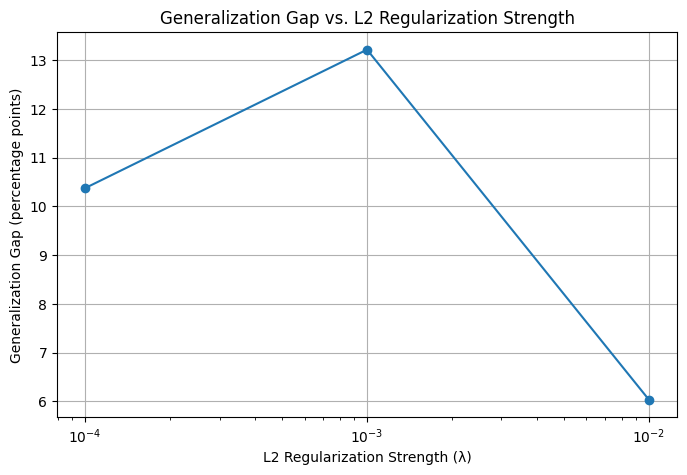

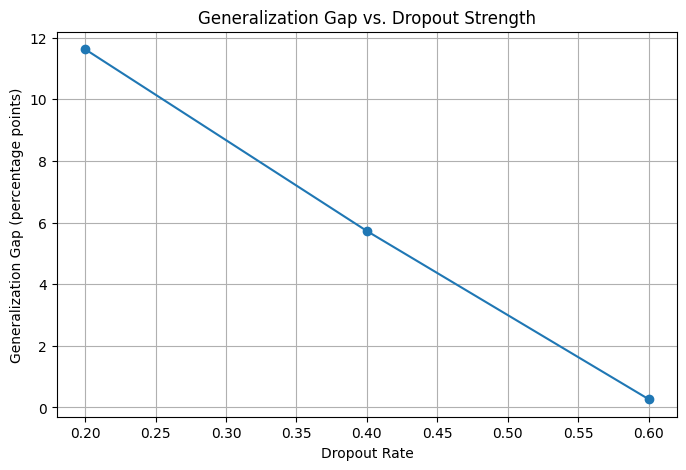

In [101]:
# ============================================================
# PART 6: GENERALIZATION GAP VS STRENGTH
# Step 18: L2 and Dropout Plots
# ============================================================

import matplotlib.pyplot as plt

# ------------------------------------------------------------
# L2 Generalization Gap
# ------------------------------------------------------------

l2_strengths = []
l2_gaps = []

for l2_lambda, result in l2_results.items():

    train_acc = result["train_accuracies"][-1]
    val_acc = result["val_accuracies"][-1]

    l2_strengths.append(l2_lambda)
    l2_gaps.append(train_acc - val_acc)


plt.figure(figsize=(8, 5))

plt.plot(
    l2_strengths,
    l2_gaps,
    marker="o"
)

plt.xscale("log")

plt.xlabel("L2 Regularization Strength (λ)")
plt.ylabel("Generalization Gap (percentage points)")
plt.title("Generalization Gap vs. L2 Regularization Strength")

plt.grid(True)
plt.show()


# ------------------------------------------------------------
# Dropout Generalization Gap
# ------------------------------------------------------------

dropout_strengths = []
dropout_gaps = []

for dropout_rate, result in dropout_results.items():

    train_acc = result["train_accuracies"][-1]
    val_acc = result["val_accuracies"][-1]

    dropout_strengths.append(dropout_rate)
    dropout_gaps.append(train_acc - val_acc)


plt.figure(figsize=(8, 5))

plt.plot(
    dropout_strengths,
    dropout_gaps,
    marker="o"
)

plt.xlabel("Dropout Rate")
plt.ylabel("Generalization Gap (percentage points)")
plt.title("Generalization Gap vs. Dropout Strength")

plt.grid(True)
plt.show()

Part 6 : Final Comparison

Step 19: Automatically identify the method that reduced the gap most efficiently

In [103]:
# ============================================================
# PART 6: FINAL COMPARISON
# Step 19: Find the Best Regularization Method
# ============================================================

# Baseline values
baseline_train = final_train_accuracy
baseline_gap = generalization_gap

# Calculate reduction in gap and loss in training accuracy
comparison = regularization_table.copy()

comparison["Gap Reduction (pp)"] = (
    baseline_gap - comparison["Generalization Gap (pp)"]
)

comparison["Training Accuracy Loss (pp)"] = (
    baseline_train - comparison["Train Accuracy (%)"]
)

# Do not consider the baseline itself
comparison = comparison[
    comparison["Method"] != "Baseline"
].copy()

# Efficiency:
# We want a large gap reduction while losing as little
# training accuracy as possible.
comparison["Efficiency"] = (
    comparison["Gap Reduction (pp)"] /
    (comparison["Training Accuracy Loss (pp)"] + 0.01)
)

# Sort by highest efficiency
comparison = comparison.sort_values(
    by="Efficiency",
    ascending=False
)

# Display comparison
display(
    comparison[
        [
            "Method",
            "Setting",
            "Train Accuracy (%)",
            "Validation Accuracy (%)",
            "Generalization Gap (pp)",
            "Gap Reduction (pp)",
            "Training Accuracy Loss (pp)"
        ]
    ].round(2)
)

# Best method
best_regularization = comparison.iloc[0]

print("\nBest Regularization Method")
print("-" * 60)

print(
    f"Method: {best_regularization['Method']}"
)

print(
    f"Setting: {best_regularization['Setting']}"
)

print(
    f"Gap Reduction: "
    f"{best_regularization['Gap Reduction (pp)']:.2f} pp"
)

print(
    f"Training Accuracy Loss: "
    f"{best_regularization['Training Accuracy Loss (pp)']:.2f} pp"
)

,Method,Setting,Train Accuracy (%),Validation Accuracy (%),Generalization Gap (pp),Gap Reduction (pp),Training Accuracy Loss (pp)
14,More Data,"20,000 samples",95.28,87.41,7.88,7.88,1.07
13,More Data,"10,000 samples",94.72,85.19,9.53,6.23,1.63
2,L2,λ = 0.001,94.80,81.58,13.22,2.54,1.55
10,Batch Normalization,BatchNorm,98.15,79.66,18.49,-2.73,-1.80
1,L2,λ = 0.0001,92.50,82.12,10.38,5.38,3.85
8,Dropout,Rate = 0.4,88.75,83.02,5.72,10.04,7.60
7,Dropout,Rate = 0.2,92.85,81.23,11.62,4.14,3.50
12,Data Augmentation,Flip + Rotation,87.70,82.08,5.62,10.14,8.65
6,L1,λ = 0.0001,90.40,81.23,9.17,6.59,5.95
11,Early Stopping,Patience = 5,88.10,81.42,6.68,9.08,8.25



Best Regularization Method
------------------------------------------------------------
Method: More Data
Setting: 20,000 samples
Gap Reduction: 7.88 pp
Training Accuracy Loss: 1.07 pp


Part 6 : Final Written Comparison

Step 20: Generate the ≤150-word comparison required by the assignment

In [104]:
# ============================================================
# PART 6: FINAL WRITTEN COMPARISON
# Step 20: Automatically Generate Report Values
# ============================================================

best_method = best_regularization["Method"]
best_setting = best_regularization["Setting"]

best_train = best_regularization["Train Accuracy (%)"]
best_val = best_regularization["Validation Accuracy (%)"]
best_gap = best_regularization["Generalization Gap (pp)"]

gap_reduction = best_regularization["Gap Reduction (pp)"]
train_loss = best_regularization["Training Accuracy Loss (pp)"]

comparison_text = f"""
Regularization methods were evaluated on the overfitted neural network
using the same architecture and training settings. The baseline model
showed a large generalization gap between training and validation
performance, indicating high variance. L2 and L1 regularization reduced
overfitting by constraining model weights, while dropout reduced reliance
on individual neurons. Batch normalization improved training stability,
and early stopping prevented unnecessary training after validation
performance stopped improving. Data augmentation increased training
variation through random flips and rotations, while increasing the
training set size provided the model with more examples. Among the
tested configurations, {best_method} ({best_setting}) provided the best
trade-off between reducing the generalization gap and preserving
training accuracy. It achieved {best_train:.2f}% training accuracy and
{best_val:.2f}% validation accuracy, with a {best_gap:.2f} percentage-point
gap. The gap was reduced by {gap_reduction:.2f} percentage points while
training accuracy decreased by only {train_loss:.2f} percentage points.
"""

print(comparison_text)

print("\nWord Count:",
      len(comparison_text.split()))


Regularization methods were evaluated on the overfitted neural network
using the same architecture and training settings. The baseline model
showed a large generalization gap between training and validation
performance, indicating high variance. L2 and L1 regularization reduced
overfitting by constraining model weights, while dropout reduced reliance
on individual neurons. Batch normalization improved training stability,
and early stopping prevented unnecessary training after validation
performance stopped improving. Data augmentation increased training
variation through random flips and rotations, while increasing the
training set size provided the model with more examples. Among the
tested configurations, More Data (20,000 samples) provided the best
trade-off between reducing the generalization gap and preserving
training accuracy. It achieved 95.28% training accuracy and
87.41% validation accuracy, with a 7.88 percentage-point
gap. The gap was reduced by 7.88 percentage points whil

Part 7 : Hyperparameter Tuning
Step 1: Define the Random Search Space

In [105]:
# ============================================================
# PART 7: HYPERPARAMETER TUNING
# Step 1: Define Random Search Space
# ============================================================

import random
from sklearn.model_selection import StratifiedKFold

# ------------------------------------------------------------
# Random seed for reproducibility
# ------------------------------------------------------------

random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)


# ------------------------------------------------------------
# Hyperparameter Search Space
# ------------------------------------------------------------

SEARCH_SPACE = {
    "learning_rate": [
        0.0001,
        0.0005,
        0.001,
        0.005
    ],

    "batch_size": [
        32,
        64,
        128
    ],

    "dropout_rate": [
        0.0,
        0.2,
        0.4,
        0.5
    ],

    "hidden_size": [
        128,
        256,
        512
    ]
}


# ------------------------------------------------------------
# Number of random configurations
# ------------------------------------------------------------

N_RANDOM_CONFIGS = 12

# Number of folds for cross-validation
N_FOLDS = 5

# Number of epochs for each CV training
CV_EPOCHS = 5


# ------------------------------------------------------------
# Generate random configurations
# ------------------------------------------------------------

random_configs = []

for i in range(N_RANDOM_CONFIGS):

    config = {
        "learning_rate": random.choice(
            SEARCH_SPACE["learning_rate"]
        ),

        "batch_size": random.choice(
            SEARCH_SPACE["batch_size"]
        ),

        "dropout_rate": random.choice(
            SEARCH_SPACE["dropout_rate"]
        ),

        "hidden_size": random.choice(
            SEARCH_SPACE["hidden_size"]
        )
    }

    random_configs.append(config)


# ------------------------------------------------------------
# Remove duplicate configurations
# ------------------------------------------------------------

unique_configs = []

for config in random_configs:

    if config not in unique_configs:
        unique_configs.append(config)

# If duplicates reduced the number below 12,
# keep generating until we have exactly 12.
while len(unique_configs) < N_RANDOM_CONFIGS:

    config = {
        "learning_rate": random.choice(
            SEARCH_SPACE["learning_rate"]
        ),

        "batch_size": random.choice(
            SEARCH_SPACE["batch_size"]
        ),

        "dropout_rate": random.choice(
            SEARCH_SPACE["dropout_rate"]
        ),

        "hidden_size": random.choice(
            SEARCH_SPACE["hidden_size"]
        )
    }

    if config not in unique_configs:
        unique_configs.append(config)


random_configs = unique_configs


# ------------------------------------------------------------
# Display search space and configurations
# ------------------------------------------------------------

print("=" * 70)
print("PART 7: HYPERPARAMETER RANDOM SEARCH")
print("=" * 70)

print("\nSearch Space:")
for parameter, values in SEARCH_SPACE.items():
    print(f"{parameter}: {values}")

print(f"\nNumber of random configurations: {N_RANDOM_CONFIGS}")
print(f"Number of CV folds: {N_FOLDS}")
print(f"CV epochs per configuration: {CV_EPOCHS}")

print("\nRandomly Selected Configurations:")
print("-" * 70)

for i, config in enumerate(random_configs, start=1):
    print(
        f"{i:02d}. "
        f"LR={config['learning_rate']}, "
        f"Batch={config['batch_size']}, "
        f"Dropout={config['dropout_rate']}, "
        f"Hidden={config['hidden_size']}"
    )

PART 7: HYPERPARAMETER RANDOM SEARCH

Search Space:
learning_rate: [0.0001, 0.0005, 0.001, 0.005]
batch_size: [32, 64, 128]
dropout_rate: [0.0, 0.2, 0.4, 0.5]
hidden_size: [128, 256, 512]

Number of random configurations: 12
Number of CV folds: 5
CV epochs per configuration: 5

Randomly Selected Configurations:
----------------------------------------------------------------------
01. LR=0.0001, Batch=32, Dropout=0.4, Hidden=128
02. LR=0.0005, Batch=32, Dropout=0.0, Hidden=512
03. LR=0.0001, Batch=128, Dropout=0.5, Hidden=128
04. LR=0.0001, Batch=32, Dropout=0.2, Hidden=128
05. LR=0.0001, Batch=128, Dropout=0.2, Hidden=512
06. LR=0.005, Batch=32, Dropout=0.5, Hidden=512
07. LR=0.001, Batch=32, Dropout=0.2, Hidden=512
08. LR=0.005, Batch=64, Dropout=0.4, Hidden=128
09. LR=0.0005, Batch=64, Dropout=0.0, Hidden=128
10. LR=0.005, Batch=32, Dropout=0.4, Hidden=256
11. LR=0.001, Batch=32, Dropout=0.5, Hidden=512
12. LR=0.0001, Batch=64, Dropout=0.0, Hidden=512


Part 7 : 5-Fold Cross-Validation

Step 2: Evaluate all 12 random configurations

In [107]:
# ============================================================
# PART 7: 5-FOLD CROSS-VALIDATION
# Step 2: Evaluate Random Configurations
# ============================================================

from sklearn.model_selection import StratifiedKFold
import time

# ------------------------------------------------------------
# Model for hyperparameter tuning
# ------------------------------------------------------------

class TunedNetwork(nn.Module):
    def __init__(self, hidden_size, dropout_rate):
        super().__init__()

        self.network = nn.Sequential(
            nn.Linear(784, hidden_size),
            nn.ReLU(),
            nn.Dropout(dropout_rate),

            nn.Linear(hidden_size, hidden_size),
            nn.ReLU(),
            nn.Dropout(dropout_rate),

            nn.Linear(hidden_size, 10)
        )

    def forward(self, x):
        return self.network(x)


# ------------------------------------------------------------
# Function to train one fold
# ------------------------------------------------------------

def train_one_fold(
    X_fold_train,
    y_fold_train,
    X_fold_val,
    y_fold_val,
    config
):

    model = TunedNetwork(
        hidden_size=config["hidden_size"],
        dropout_rate=config["dropout_rate"]
    )

    criterion = nn.CrossEntropyLoss()

    optimizer = optim.Adam(
        model.parameters(),
        lr=config["learning_rate"]
    )

    train_dataset = TensorDataset(
        torch.tensor(X_fold_train, dtype=torch.float32),
        torch.tensor(y_fold_train, dtype=torch.long)
    )

    val_dataset = TensorDataset(
        torch.tensor(X_fold_val, dtype=torch.float32),
        torch.tensor(y_fold_val, dtype=torch.long)
    )

    train_loader_cv = DataLoader(
        train_dataset,
        batch_size=config["batch_size"],
        shuffle=True
    )

    val_loader_cv = DataLoader(
        val_dataset,
        batch_size=config["batch_size"],
        shuffle=False
    )

    # --------------------------------------------------------
    # Training
    # --------------------------------------------------------

    for epoch in range(CV_EPOCHS):

        model.train()

        for X_batch, y_batch in train_loader_cv:

            optimizer.zero_grad()

            outputs = model(X_batch)

            loss = criterion(outputs, y_batch)

            loss.backward()

            optimizer.step()


    # --------------------------------------------------------
    # Validation accuracy
    # --------------------------------------------------------

    model.eval()

    correct = 0
    total = 0

    with torch.no_grad():

        for X_batch, y_batch in val_loader_cv:

            outputs = model(X_batch)

            predictions = torch.argmax(
                outputs,
                dim=1
            )

            correct += (
                (predictions == y_batch).sum().item()
            )

            total += y_batch.size(0)

    accuracy = (correct / total) * 100

    return accuracy


# ------------------------------------------------------------
# Prepare 5-fold cross-validation
# ------------------------------------------------------------

skf = StratifiedKFold(
    n_splits=N_FOLDS,
    shuffle=True,
    random_state=SEED
)


# ------------------------------------------------------------
# Run 5-fold CV for all 12 configurations
# ------------------------------------------------------------

cv_results = []

print("=" * 70)
print("Starting 5-Fold Cross-Validation")
print("=" * 70)

overall_start = time.time()

for config_number, config in enumerate(
    random_configs,
    start=1
):

    print(
        f"\nConfiguration {config_number}/{N_RANDOM_CONFIGS}"
    )

    print(
        f"LR={config['learning_rate']}, "
        f"Batch={config['batch_size']}, "
        f"Dropout={config['dropout_rate']}, "
        f"Hidden={config['hidden_size']}"
    )

    fold_scores = []

    config_start = time.time()

    # --------------------------------------------------------
    # Create 5 folds from the training data
    # --------------------------------------------------------

    for fold_number, (train_idx, val_idx) in enumerate(
        skf.split(X_train, y_train),
        start=1
    ):

        print(
            f"  Fold {fold_number}/{N_FOLDS}...",
            end=" "
        )

        score = train_one_fold(
            X_train[train_idx],
            y_train[train_idx],
            X_train[val_idx],
            y_train[val_idx],
            config
        )

        fold_scores.append(score)

        print(f"{score:.2f}%")


    # --------------------------------------------------------
    # Calculate mean and standard deviation
    # --------------------------------------------------------

    mean_score = np.mean(fold_scores)
    std_score = np.std(fold_scores)

    config_time = time.time() - config_start

    cv_results.append({
        "Configuration": config_number,
        "Learning Rate": config["learning_rate"],
        "Batch Size": config["batch_size"],
        "Dropout Rate": config["dropout_rate"],
        "Hidden Size": config["hidden_size"],
        "Mean CV Accuracy (%)": mean_score,
        "Std CV Accuracy (%)": std_score,
        "Time (seconds)": config_time
    })

    print(
        f"  Mean CV Accuracy: {mean_score:.2f}%"
    )

    print(
        f"  Std CV Accuracy: {std_score:.2f}%"
    )


overall_time = time.time() - overall_start

print("\n" + "=" * 70)
print("5-Fold Cross-Validation Completed")
print("=" * 70)

print(
    f"Total Time: {overall_time / 60:.2f} minutes"
)


# ------------------------------------------------------------
# Create results table
# ------------------------------------------------------------

cv_results_table = pd.DataFrame(cv_results)

cv_results_table = cv_results_table.sort_values(
    by="Mean CV Accuracy (%)",
    ascending=False
).reset_index(drop=True)

display(
    cv_results_table.round(2)
)

Starting 5-Fold Cross-Validation

Configuration 1/12
LR=0.0001, Batch=32, Dropout=0.4, Hidden=128
  Fold 1/5... 84.34%
  Fold 2/5... 84.30%
  Fold 3/5... 84.08%
  Fold 4/5... 83.50%
  Fold 5/5... 84.02%
  Mean CV Accuracy: 84.05%
  Std CV Accuracy: 0.30%

Configuration 2/12
LR=0.0005, Batch=32, Dropout=0.0, Hidden=512
  Fold 1/5... 87.82%
  Fold 2/5... 88.09%
  Fold 3/5... 88.51%
  Fold 4/5... 86.36%
  Fold 5/5... 87.85%
  Mean CV Accuracy: 87.73%
  Std CV Accuracy: 0.73%

Configuration 3/12
LR=0.0001, Batch=128, Dropout=0.5, Hidden=128
  Fold 1/5... 80.22%
  Fold 2/5... 80.02%
  Fold 3/5... 79.38%
  Fold 4/5... 79.06%
  Fold 5/5... 80.06%
  Mean CV Accuracy: 79.75%
  Std CV Accuracy: 0.45%

Configuration 4/12
LR=0.0001, Batch=32, Dropout=0.2, Hidden=128
  Fold 1/5... 85.15%
  Fold 2/5... 84.83%
  Fold 3/5... 84.81%
  Fold 4/5... 84.04%
  Fold 5/5... 85.05%
  Mean CV Accuracy: 84.78%
  Std CV Accuracy: 0.39%

Configuration 5/12
LR=0.0001, Batch=128, Dropout=0.2, Hidden=512
  Fold 1/5..

,Configuration,Learning Rate,Batch Size,Dropout Rate,Hidden Size,Mean CV Accuracy (%),Std CV Accuracy (%),Time (seconds)
0,2,0.0,32,0.0,512,87.73,0.73,165.68
1,7,0.0,32,0.2,512,87.30,0.50,249.59
2,9,0.0,64,0.0,128,86.72,0.44,45.09
3,11,0.0,32,0.5,512,86.53,0.22,266.96
4,12,0.0,64,0.0,512,86.33,0.14,79.00
5,5,0.0,128,0.2,512,85.54,0.26,66.78
6,4,0.0,32,0.2,128,84.78,0.39,79.39
7,8,0.0,64,0.4,128,84.12,0.36,60.13
8,1,0.0,32,0.4,128,84.05,0.30,82.83
9,10,0.0,32,0.4,256,82.84,0.61,156.56


Part 7 : Top 5 Configurations

Step 3: Report the top 5 based on mean 5-fold CV accuracy

In [108]:
# ============================================================
# PART 7: TOP 5 HYPERPARAMETER CONFIGURATIONS
# Step 3: Select and Report Top 5
# ============================================================

# ------------------------------------------------------------
# Select top 5 configurations
# ------------------------------------------------------------

top5_cv_results = cv_results_table.head(5).copy()

# ------------------------------------------------------------
# Display required results
# ------------------------------------------------------------

print("=" * 70)
print("TOP 5 HYPERPARAMETER CONFIGURATIONS")
print("=" * 70)

display(
    top5_cv_results[
        [
            "Configuration",
            "Learning Rate",
            "Batch Size",
            "Dropout Rate",
            "Hidden Size",
            "Mean CV Accuracy (%)",
            "Std CV Accuracy (%)"
        ]
    ].round(2)
)


# ------------------------------------------------------------
# Select the best configuration
# ------------------------------------------------------------

best_cv_row = top5_cv_results.iloc[0]

best_config_number = int(
    best_cv_row["Configuration"]
)

selected_config = random_configs[
    best_config_number - 1
]


print("\nSelected Configuration")
print("-" * 70)

print(
    f"Configuration: {best_config_number}"
)

print(
    f"Learning Rate: {selected_config['learning_rate']}"
)

print(
    f"Batch Size: {selected_config['batch_size']}"
)

print(
    f"Dropout Rate: {selected_config['dropout_rate']}"
)

print(
    f"Hidden Size: {selected_config['hidden_size']}"
)

print(
    f"Mean 5-Fold CV Accuracy: "
    f"{best_cv_row['Mean CV Accuracy (%)']:.2f}%"
)

print(
    f"CV Standard Deviation: "
    f"{best_cv_row['Std CV Accuracy (%)']:.2f}%"
)

TOP 5 HYPERPARAMETER CONFIGURATIONS


,Configuration,Learning Rate,Batch Size,Dropout Rate,Hidden Size,Mean CV Accuracy (%),Std CV Accuracy (%)
0,2,0.0,32,0.0,512,87.73,0.73
1,7,0.0,32,0.2,512,87.30,0.50
2,9,0.0,64,0.0,128,86.72,0.44
3,11,0.0,32,0.5,512,86.53,0.22
4,12,0.0,64,0.0,512,86.33,0.14



Selected Configuration
----------------------------------------------------------------------
Configuration: 2
Learning Rate: 0.0005
Batch Size: 32
Dropout Rate: 0.0
Hidden Size: 512
Mean 5-Fold CV Accuracy: 87.73%
CV Standard Deviation: 0.73%


Part 7 : Final Model Training

Step 4: Retrain the selected configuration on the full training set

In [109]:
# ============================================================
# PART 7: FINAL MODEL
# Step 4: Retrain Selected Configuration on Full Training Set
# ============================================================

# ------------------------------------------------------------
# Use the selected hyperparameters
# ------------------------------------------------------------

FINAL_LR = selected_config["learning_rate"]
FINAL_BATCH_SIZE = selected_config["batch_size"]
FINAL_DROPOUT = selected_config["dropout_rate"]
FINAL_HIDDEN_SIZE = selected_config["hidden_size"]

print("=" * 70)
print("FINAL MODEL TRAINING")
print("=" * 70)

print("\nSelected Hyperparameters:")
print(f"Learning Rate: {FINAL_LR}")
print(f"Batch Size:    {FINAL_BATCH_SIZE}")
print(f"Dropout Rate:  {FINAL_DROPOUT}")
print(f"Hidden Size:   {FINAL_HIDDEN_SIZE}")

print(
    f"\nBest Regularization from Part 6: "
    f"{best_method} ({best_setting})"
)


# ------------------------------------------------------------
# Final model
# ------------------------------------------------------------

final_model = TunedNetwork(
    hidden_size=FINAL_HIDDEN_SIZE,
    dropout_rate=FINAL_DROPOUT
)


# ------------------------------------------------------------
# Full training dataset
# ------------------------------------------------------------

full_train_dataset = TensorDataset(
    torch.tensor(X_train, dtype=torch.float32),
    torch.tensor(y_train, dtype=torch.long)
)

full_train_loader = DataLoader(
    full_train_dataset,
    batch_size=FINAL_BATCH_SIZE,
    shuffle=True
)


# ------------------------------------------------------------
# Loss and optimizer
# ------------------------------------------------------------

criterion = nn.CrossEntropyLoss()

optimizer = optim.Adam(
    final_model.parameters(),
    lr=FINAL_LR
)


# ------------------------------------------------------------
# Apply best regularization
# ------------------------------------------------------------

# L2 regularization
if best_method == "L2":

    l2_value = float(
        best_setting.split("=")[1].strip()
    )

    optimizer = optim.Adam(
        final_model.parameters(),
        lr=FINAL_LR,
        weight_decay=l2_value
    )

    print(f"\nApplying L2 regularization: λ = {l2_value}")


# L1 regularization will be added manually during training
if best_method == "L1":

    l1_value = float(
        best_setting.split("=")[1].strip()
    )

    print(f"\nApplying L1 regularization: λ = {l1_value}")


# ------------------------------------------------------------
# Train on full training set
# ------------------------------------------------------------

FINAL_EPOCHS = 30

final_train_losses = []
final_train_accuracies = []

print("\nTraining final model...")

for epoch in range(FINAL_EPOCHS):

    final_model.train()

    running_loss = 0.0
    correct = 0
    total = 0

    for X_batch, y_batch in full_train_loader:

        optimizer.zero_grad()

        outputs = final_model(X_batch)

        loss = criterion(outputs, y_batch)

        # Apply L1 penalty if selected
        if best_method == "L1":

            l1_penalty = sum(
                torch.sum(torch.abs(parameter))
                for parameter in final_model.parameters()
            )

            loss = loss + l1_value * l1_penalty

        loss.backward()

        optimizer.step()

        running_loss += loss.item() * X_batch.size(0)

        predictions = torch.argmax(
            outputs,
            dim=1
        )

        correct += (
            (predictions == y_batch).sum().item()
        )

        total += y_batch.size(0)

    epoch_loss = running_loss / total
    epoch_accuracy = (correct / total) * 100

    final_train_losses.append(epoch_loss)
    final_train_accuracies.append(epoch_accuracy)

    print(
        f"Epoch {epoch + 1:02d}/{FINAL_EPOCHS} | "
        f"Loss: {epoch_loss:.4f} | "
        f"Accuracy: {epoch_accuracy:.2f}%"
    )


print("\nFinal model training completed.")

FINAL MODEL TRAINING

Selected Hyperparameters:
Learning Rate: 0.0005
Batch Size:    32
Dropout Rate:  0.0
Hidden Size:   512

Best Regularization from Part 6: More Data (20,000 samples)

Training final model...
Epoch 01/30 | Loss: 0.5152 | Accuracy: 81.49%
Epoch 02/30 | Loss: 0.3740 | Accuracy: 86.36%
Epoch 03/30 | Loss: 0.3322 | Accuracy: 87.85%
Epoch 04/30 | Loss: 0.3081 | Accuracy: 88.65%
Epoch 05/30 | Loss: 0.2852 | Accuracy: 89.40%
Epoch 06/30 | Loss: 0.2699 | Accuracy: 89.93%
Epoch 07/30 | Loss: 0.2547 | Accuracy: 90.44%
Epoch 08/30 | Loss: 0.2399 | Accuracy: 90.92%
Epoch 09/30 | Loss: 0.2287 | Accuracy: 91.36%
Epoch 10/30 | Loss: 0.2190 | Accuracy: 91.83%
Epoch 11/30 | Loss: 0.2067 | Accuracy: 92.18%
Epoch 12/30 | Loss: 0.1972 | Accuracy: 92.47%
Epoch 13/30 | Loss: 0.1889 | Accuracy: 92.79%
Epoch 14/30 | Loss: 0.1773 | Accuracy: 93.20%
Epoch 15/30 | Loss: 0.1698 | Accuracy: 93.60%
Epoch 16/30 | Loss: 0.1651 | Accuracy: 93.58%
Epoch 17/30 | Loss: 0.1563 | Accuracy: 94.00%
Epoch 

Part 7 : Held-Out Test Evaluation

Step 5: Evaluate the final model once on the untouched test set

FINAL TEST RESULTS
Test Accuracy:          89.87%
Macro Precision:         0.9002
Macro Recall:            0.8987
Macro F1-Score:          0.8988
Part 2 Baseline:         89.01%
Improvement over Baseline: +0.86 percentage points

Confusion Matrix:
[[853   0  11  26   3   0 103   0   4   0]
 [  3 987   1   6   1   0   1   0   1   0]
 [ 26   0 767  17 118   0  70   0   2   0]
 [ 13  10   4 917  35   0  20   0   1   0]
 [  2   1  47  15 882   0  52   0   1   0]
 [  0   0   0   0   0 947   1  40   1  11]
 [101   2  49  27  65   0 754   0   2   0]
 [  0   0   0   0   0  10   0 968   0  22]
 [ 12   0   5   1   4   2   9   2 963   2]
 [  1   0   0   0   0   5   0  45   0 949]]


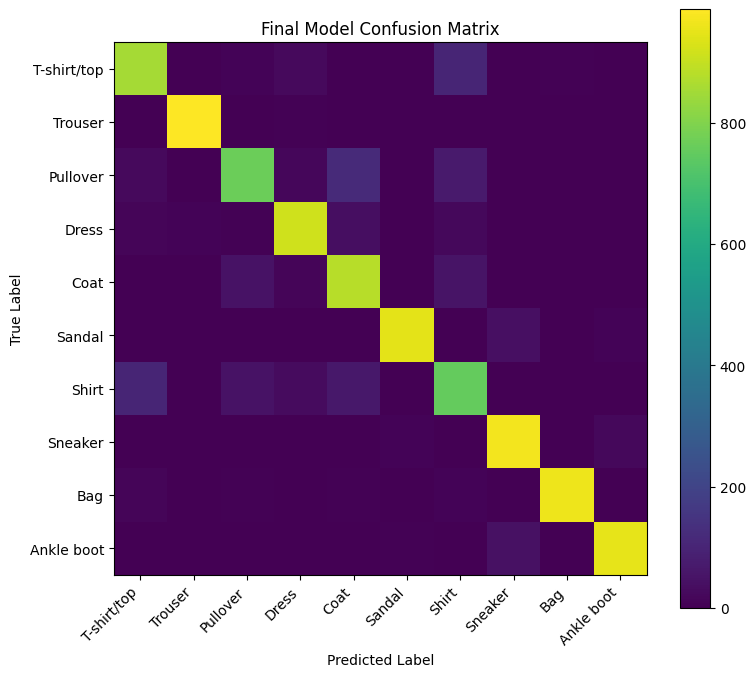

In [110]:
# ============================================================
# PART 7: FINAL TEST EVALUATION
# Step 5: Evaluate Once on Held-Out Test Set
# ============================================================

from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    confusion_matrix
)

# ------------------------------------------------------------
# Create untouched test DataLoader
# ------------------------------------------------------------

test_dataset = TensorDataset(
    torch.tensor(X_test, dtype=torch.float32),
    torch.tensor(y_test, dtype=torch.long)
)

test_loader = DataLoader(
    test_dataset,
    batch_size=FINAL_BATCH_SIZE,
    shuffle=False
)


# ------------------------------------------------------------
# Evaluate final model
# ------------------------------------------------------------

final_model.eval()

all_test_predictions = []
all_test_labels = []

with torch.no_grad():

    for X_batch, y_batch in test_loader:

        outputs = final_model(X_batch)

        predictions = torch.argmax(
            outputs,
            dim=1
        )

        all_test_predictions.extend(
            predictions.cpu().numpy()
        )

        all_test_labels.extend(
            y_batch.cpu().numpy()
        )


# Convert to NumPy arrays
all_test_predictions = np.array(all_test_predictions)
all_test_labels = np.array(all_test_labels)


# ------------------------------------------------------------
# Calculate required metrics
# ------------------------------------------------------------

test_accuracy = accuracy_score(
    all_test_labels,
    all_test_predictions
) * 100

test_precision = precision_score(
    all_test_labels,
    all_test_predictions,
    average="macro"
)

test_recall = recall_score(
    all_test_labels,
    all_test_predictions,
    average="macro"
)

test_f1 = f1_score(
    all_test_labels,
    all_test_predictions,
    average="macro"
)

test_cm = confusion_matrix(
    all_test_labels,
    all_test_predictions
)


# ------------------------------------------------------------
# Compare with Part 2 baseline
# ------------------------------------------------------------

improvement_pp = (
    test_accuracy - part2_baseline_accuracy
)


# ------------------------------------------------------------
# Display final results
# ------------------------------------------------------------

print("=" * 70)
print("FINAL TEST RESULTS")
print("=" * 70)

print(
    f"Test Accuracy:          {test_accuracy:.2f}%"
)

print(
    f"Macro Precision:         {test_precision:.4f}"
)

print(
    f"Macro Recall:            {test_recall:.4f}"
)

print(
    f"Macro F1-Score:          {test_f1:.4f}"
)

print(
    f"Part 2 Baseline:         "
    f"{part2_baseline_accuracy:.2f}%"
)

print(
    f"Improvement over Baseline: "
    f"{improvement_pp:+.2f} percentage points"
)


# ------------------------------------------------------------
# Confusion Matrix
# ------------------------------------------------------------

print("\nConfusion Matrix:")
print(test_cm)

plt.figure(figsize=(8, 7))

plt.imshow(test_cm)

plt.title("Final Model Confusion Matrix")
plt.xlabel("Predicted Label")
plt.ylabel("True Label")

plt.xticks(
    range(10),
    CLASS_NAMES,
    rotation=45,
    ha="right"
)

plt.yticks(
    range(10),
    CLASS_NAMES
)

plt.colorbar()

plt.tight_layout()
plt.show()

Part 7 : Final Summary

Step 6: Create the final results table for the report

In [111]:
# ============================================================
# PART 7: FINAL SUMMARY
# Step 6: Create Final Results Summary
# ============================================================

final_summary = pd.DataFrame({
    "Metric": [
        "Selected Learning Rate",
        "Selected Batch Size",
        "Selected Dropout Rate",
        "Selected Hidden Size",
        "Best Regularization",
        "Mean 5-Fold CV Accuracy (%)",
        "CV Standard Deviation (%)",
        "Final Test Accuracy (%)",
        "Macro Precision",
        "Macro Recall",
        "Macro F1-Score",
        "Improvement over Part 2 Baseline (pp)"
    ],

    "Value": [
        FINAL_LR,
        FINAL_BATCH_SIZE,
        FINAL_DROPOUT,
        FINAL_HIDDEN_SIZE,
        f"{best_method} ({best_setting})",
        best_cv_row["Mean CV Accuracy (%)"],
        best_cv_row["Std CV Accuracy (%)"],
        test_accuracy,
        test_precision,
        test_recall,
        test_f1,
        improvement_pp
    ]
})

display(final_summary.round(4))


# ------------------------------------------------------------
# Final conclusion
# ------------------------------------------------------------

print("=" * 70)
print("ASSIGNMENT FINAL CONCLUSION")
print("=" * 70)

print(
    f"Final Test Accuracy: {test_accuracy:.2f}%"
)

print(
    f"Macro F1-Score: {test_f1:.4f}"
)

print(
    f"Improvement over Part 2 Baseline: "
    f"{improvement_pp:+.2f} percentage points"
)

if improvement_pp > 0:
    print(
        "\nThe tuned and regularized model improved "
        "over the Part 2 baseline."
    )
elif improvement_pp < 0:
    print(
        "\nThe tuned model performed below the Part 2 "
        "baseline, showing that hyperparameter tuning "
        "did not improve generalization in this experiment."
    )
else:
    print(
        "\nThe tuned model achieved the same accuracy "
        "as the Part 2 baseline."
    )

,Metric,Value
0,Selected Learning Rate,0.0005
1,Selected Batch Size,32
2,Selected Dropout Rate,0.0
3,Selected Hidden Size,512
4,Best Regularization,"More Data (20,000 samples)"
5,Mean 5-Fold CV Accuracy (%),87.729167
6,CV Standard Deviation (%),0.725227
7,Final Test Accuracy (%),89.87
8,Macro Precision,0.900177
9,Macro Recall,0.8987


ASSIGNMENT FINAL CONCLUSION
Final Test Accuracy: 89.87%
Macro F1-Score: 0.8988
Improvement over Part 2 Baseline: +0.86 percentage points

The tuned and regularized model improved over the Part 2 baseline.
